In [1]:
import pandas as pd
import os
import pyarrow.parquet as pq



common_stage_path = '/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/common_stage'
files = sorted(os.listdir(common_stage_path))
print(f"Number of files: {len(files)}")
print("First few files:", files[:5])

table = pq.read_table(f"{common_stage_path}/{files[0]}")
df = table.to_pandas()
print(df.shape)
df.head(10)

Number of files: 250
First few files: ['part-0.parquet', 'part-1.parquet', 'part-10.parquet', 'part-100.parquet', 'part-101.parquet']
(91798, 203)


,patientid,datetime,HR,T Central,ABPs,ABPd,ABPm,NIBPs,NIBPd,NIBPm,...,Terlipressin,Immunoglobulin,Immunsuppression,VitB Substitution,Parkinson Medikaiton,GCSF,admissiontime,age,sex,height
0,148,0.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
1,148,5.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
2,148,10.0,127.0,NaN,155.0,99.0,119.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
3,148,15.0,119.0,NaN,150.0,99.0,117.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
4,148,20.0,118.0,NaN,151.0,99.0,117.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
5,148,25.0,116.0,NaN,145.0,88.0,112.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
6,148,30.0,105.0,NaN,116.0,74.0,87.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
7,148,35.0,101.0,NaN,110.0,70.0,83.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
8,148,40.0,100.0,NaN,103.0,64.0,77.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN
9,148,45.0,97.0,NaN,99.0,61.0,73.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,162.0,50,M,NaN


In [5]:
general = pd.read_csv('/home/bbe9928/hirid_raw/general_table.csv')
print(general.columns.tolist())
print(general.head())

['patientid', 'admissiontime', 'sex', 'age', 'discharge_status']
   patientid        admissiontime sex  age discharge_status
0          1  2197-04-03 19:15:00   M   75            alive
1          2  2117-10-18 22:35:00   M   80            alive
2          3  2163-10-17 19:15:00   M   55            alive
3          4  2149-01-08 15:30:00   M   75            alive
4          5  2144-06-06 16:15:00   M   20            alive


In [6]:
varref = pd.read_csv('/home/bbe9928/hirid_raw/hirid_variable_reference.csv')
print(varref.columns.tolist())
# Search for apache
apache_vars = varref[varref['variablename'].str.lower().str.contains('apache', na=False)]
print(apache_vars)

['Source Table', 'ID', 'Variable Name', 'Unit', 'Additional information']


KeyError: 'variablename'

In [11]:
for i in range(len(df.columns)):
    print(f'{i}: {df.columns[i]}')

0: patientid
1: datetime
2: HR
3: T Central
4: ABPs
5: ABPd
6: ABPm
7: NIBPs
8: NIBPd
9: NIBPm
10: PAPm
11: PAPs
12: PAPd
13: PCWP
14: CO
15: SvO2(m)
16: ZVD
17: ST1
18: ST2
19: ST3
20: Rhythmus
21: SpO2
22: ETCO2
23: RR
24: supplemental oxygen
25: OUTurine/h
26: GCS Antwort
27: GCS Motorik
28: GCS Augen�ffnen
29: RASS
30: ICP
31: TOF
32: IN
33: OUT
34: Incrys
35: Incolloid
36: FIO2
37: Peep
38: Ventilator mode
39: TV
40: Spitzendruck
41: Plateaudruck
42: AWPmean
43: RR set
44: AiwayCode
45: Haemofiltration
46: Liquor/h
47: Weight
48: a-BE
49: a_COHb
50: a_Hb
51: a_HCO3-
52: a_Lac
53: a_MetHb
54: a_pH
55: a_pCO2
56: a_PO2
57: a_SO2
58: Zentral venöse sättigung
59: Troponin-T
60: creatine kinase
61: creatine kinase-MB
62: v-Lac
63: BNP
64: K+
65: Na+
66: Cl-
67: Ca2+ ionizied
68: Ca2+ total
69: phosphate
70: Mg_lab
71: Urea
72: creatinine
73: urinary creatinin
74: urinary Na+
75: urinary urea
76: ASAT
77: ALAT
78: bilirubine, total
79: Bilirubin, direct
80: alkaline phosphatase
81: gamm

In [10]:
import h5py
import hdf5plugin

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
for i, c in enumerate(columns):
    print(f'{i}: {c}')
f.close()

0: datetime
1: HR
2: T Central
3: ABPs
4: ABPd
5: ABPm
6: NIBPs
7: NIBPd
8: NIBPm
9: PAPm
10: PAPs
11: PAPd
12: PCWP
13: CO
14: SvO2(m)
15: ZVD
16: ST1
17: ST2
18: ST3
19: Rhythmus
20: SpO2
21: ETCO2
22: RR
23: supplemental oxygen
24: OUTurine/h
25: GCS Antwort
26: GCS Motorik
27: GCS Augen�ffnen
28: RASS
29: ICP
30: TOF
31: IN
32: OUT
33: Incrys
34: Incolloid
35: FIO2
36: Peep
37: Ventilator mode
38: TV
39: Spitzendruck
40: Plateaudruck
41: AWPmean
42: RR set
43: AiwayCode
44: Haemofiltration
45: Liquor/h
46: Weight
47: a-BE
48: a_COHb
49: a_Hb
50: a_HCO3-
51: a_Lac
52: a_MetHb
53: a_pH
54: a_pCO2
55: a_PO2
56: a_SO2
57: Zentral venöse sättigung
58: Troponin-T
59: creatine kinase
60: creatine kinase-MB
61: v-Lac
62: BNP
63: K+
64: Na+
65: Cl-
66: Ca2+ ionizied
67: Ca2+ total
68: phosphate
69: Mg_lab
70: Urea
71: creatinine
72: urinary creatinin
73: urinary Na+
74: urinary urea
75: ASAT
76: ALAT
77: bilirubine, total
78: Bilirubin, direct
79: alkaline phosphatase
80: gamma-GT
81: aPTT


In [6]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import os

common_stage_path = '/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/common_stage'
files = sorted(os.listdir(common_stage_path))
print(f"Number of batch files: {len(files)}")

# Load first batch
df = pq.read_table(f"{common_stage_path}/{files[0]}").to_pandas()
print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")

Number of batch files: 250
Shape: (91798, 203)
Columns (203): ['patientid', 'datetime', 'HR', 'T Central', 'ABPs', 'ABPd', 'ABPm', 'NIBPs', 'NIBPd', 'NIBPm', 'PAPm', 'PAPs', 'PAPd', 'PCWP', 'CO', 'SvO2(m)', 'ZVD', 'ST1', 'ST2', 'ST3', 'Rhythmus', 'SpO2', 'ETCO2', 'RR', 'supplemental oxygen', 'OUTurine/h', 'GCS Antwort', 'GCS Motorik', 'GCS Augen�ffnen', 'RASS', 'ICP', 'TOF', 'IN', 'OUT', 'Incrys', 'Incolloid', 'FIO2', 'Peep', 'Ventilator mode', 'TV', 'Spitzendruck', 'Plateaudruck', 'AWPmean', 'RR set', 'AiwayCode', 'Haemofiltration', 'Liquor/h', 'Weight', 'a-BE', 'a_COHb', 'a_Hb', 'a_HCO3-', 'a_Lac', 'a_MetHb', 'a_pH', 'a_pCO2', 'a_PO2', 'a_SO2', 'Zentral venöse sättigung', 'Troponin-T', 'creatine kinase', 'creatine kinase-MB', 'v-Lac', 'BNP', 'K+', 'Na+', 'Cl-', 'Ca2+ ionizied', 'Ca2+ total', 'phosphate', 'Mg_lab', 'Urea', 'creatinine', 'urinary creatinin', 'urinary Na+', 'urinary urea', 'ASAT', 'ALAT', 'bilirubine, total', 'Bilirubin, direct', 'alkaline phosphatase', 'gamma-GT', 'aPT

In [1]:
import numpy as np
import h5py
import hdf5plugin
import matplotlib.pyplot as plt
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX, DATETIME_IDX, DEMOGRAPHIC_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
print(f'Should be datetime: datetime_idx[0] = {DATETIME_IDX[0]}')
print(columns[DATETIME_IDX[0]])      # should be datetime
print(f'Should be HR: Measurement_idx[0] = {MEASUREMENT_IDX[0]}')
print(columns[MEASUREMENT_IDX[0]])   # should be HR
print(columns[TREATMENT_IDX[0]])     # should be supplemental oxygen
print(columns[DEMOGRAPHIC_IDX[0]])   # should be Weight
f.close()

Should be datetime: datetime_idx[0] = 0
datetime
Should be HR: Measurement_idx[0] = 1
HR
supplemental oxygen
Weight


In [7]:
# Load ml_stage columns for comparison
import h5py, hdf5plugin
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_subset.h5', 'r')
ml_columns = [c.decode('utf-8') for c in f['data']['columns'][:]]
f.close()

common_columns = df.columns.tolist()
common_columns_clean = [c for c in common_columns if c not in ['patientid', 'datetime']]

only_in_ml     = set(ml_columns) - set(common_columns_clean)
only_in_common = set(common_columns_clean) - set(ml_columns)
in_both        = set(ml_columns) & set(common_columns_clean)

print(f"Variables in ml_stage:     {len(ml_columns)}")
print(f"Variables in common_stage: {len(common_columns_clean)}")
print(f"In both:                   {len(in_both)}")
print(f"\nOnly in ml_stage (one-hot encoded or added):")
for c in sorted(only_in_ml): print(f"  {c}")
print(f"\nOnly in common_stage (raw, before one-hot):")
for c in sorted(only_in_common): print(f"  {c}")

Variables in ml_stage:     231
Variables in common_stage: 201
In both:                   139

Only in ml_stage (one-hot encoded or added):
  Acetazolamide_1.0
  Adenosin_1.0
  Administation of antimycotic_1.0
  Administriation of antibiotics_1.0
  AiwayCode_1.0
  AiwayCode_2.0
  AiwayCode_3.0
  AiwayCode_4.0
  AiwayCode_5.0
  AiwayCode_6.0
  Aldosteron Antagonist_1.0
  Amiodaron_1.0
  Andere_1.0
  Anexate_1.0
  Anti Fibrinolyticum_1.0
  Anti delirant medi_1.0
  Antihelmenticum_1.0
  Antihistaminka_1.0
  Atropin_1.0
  Barbiturate_1.0
  Beh. Pulm. Hypertonie_1.0
  Bicarbonate_1.0
  Ca_1.0
  Chemotherapie_1.0
  Digoxin_1.0
  Enteral Feeding_1.0
  GCSF_1.0
  Haemofiltration_1.0
  Immunoglobulin_1.0
  Immunsuppression_1.0
  K-sparend_1.0
  Kalium_1.0
  Lysetherapie_1.0
  Marcoumar_1.0
  Mg_1.0
  Mineralokortikoid_1.0
  Muskelrelaxans_1.0
  NMH_1.0
  NSAR_1.0
  Na_1.0
  Naloxon_1.0
  Nimodipin_1.0
  Non-opioide_1.0
  Others in Case of HIT_1.0
  Pankreas Enzyme_1.0
  Parenteral Feeding_1.0
  

In [3]:
print("Demographics columns:")
for i in [47, 199, 200, 201, 202]:
    print(f"  {i}: {df.columns[i]}")

print("\nFirst 5 measurement columns:")
for i in [2, 3, 4, 5, 6]:
    print(f"  {i}: {df.columns[i]}")

print("\nFirst 5 treatment columns:")
for i in [24, 32, 34, 35, 36]:
    print(f"  {i}: {df.columns[i]}")

print("\nSex column values:")
print(df['sex'].value_counts())

Demographics columns:
  47: Weight
  199: admissiontime
  200: age
  201: sex
  202: height

First 5 measurement columns:
  2: HR
  3: T Central
  4: ABPs
  5: ABPd
  6: ABPm

First 5 treatment columns:
  24: supplemental oxygen
  32: IN
  34: Incrys
  35: Incolloid
  36: FIO2

Sex column values:
sex
M    61805
F    29993
Name: count, dtype: int64


In [4]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

# Load several batches for representative stats
dfs = []
for fname in sorted(os.listdir(common_stage_path))[:20]:
    dfs.append(pq.read_table(f"{common_stage_path}/{fname}").to_pandas())
sample = pd.concat(dfs, ignore_index=True)

MEASUREMENT_COLS = [df.columns[i] for i in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31,
33, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100,
101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
112, 113, 114]]

stats = pd.DataFrame({
    'obs_rate': (~sample[MEASUREMENT_COLS].isna()).mean(),
    'mean':     sample[MEASUREMENT_COLS].mean(),
    'std':      sample[MEASUREMENT_COLS].std(),
    'min':      sample[MEASUREMENT_COLS].min(),
    'max':      sample[MEASUREMENT_COLS].max(),
}).sort_values('obs_rate', ascending=False)

print(stats.head(20).to_string())

           obs_rate        mean         std        min           max
HR         0.974445   85.449424   17.907620   0.000000    300.000000
SpO2       0.931621   96.393899    3.528564  10.000000    100.000000
ABPs       0.884586  118.227118   27.437754  10.000000    300.000000
ABPm       0.884365   77.727217   17.021598  10.000000    200.000000
ABPd       0.884145   57.387353   13.163387  10.000000    175.000000
ST1        0.623663    0.041179    0.598870 -11.600000     10.500000
ZVD        0.598801    8.338919    5.202555   0.000000     50.000000
RR         0.490952   16.812416   10.072400   0.000000     45.000000
ST2        0.432999    0.120718    0.609167 -17.200001     16.400000
ETCO2      0.416478   29.621761    6.790129  10.000000    100.000000
ST3        0.366280    0.123476    0.516552 -17.200001     16.100000
T Central  0.128350   37.195734    0.944602  25.000000     44.799999
PAPs       0.110340   39.580004   12.111038  10.000000    150.000000
PAPm       0.110211   26.829304   

In [5]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import os

common_stage_path = '/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/common_stage'

# Load the split file to know which patients are in train
split_df = pd.read_csv('/home/bbe9928/HIRID-ICU-Benchmark/preprocessing/resources/split.tsv', sep='\t')
print(split_df.head())
print(split_df['split'].value_counts())
print(f"Total patients: {len(split_df)}")

   Unnamed: 0  patientid  split
0           0        148  train
1           1        229  train
2           2        496  train
3           3        766  train
4           4       1342  train
split
train    23731
test      5086
val       5086
Name: count, dtype: int64
Total patients: 33903


In [6]:
sample = pq.read_table(f"{common_stage_path}/{files[0]}").to_pandas()
for col in sample.columns:
    if sample[col].dtype == object:
        print(f"{col}: {sample[col].unique()[:5]}")

sex: ['M' 'F']


In [2]:
import h5py
import hdf5plugin
import numpy as np

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')

# Structure
print("Top level keys:", list(f.keys()))
print("\nData groups:", list(f['data'].keys()))
print("Mask groups:", list(f['mask'].keys()))
print("Window groups:", list(f['windows'].keys()))

# Shapes
for split in ['train', 'val', 'test']:
    d = f['data'][split]
    m = f['mask'][split]
    w = f['windows'][split]
    print(f"\n{split}:")
    print(f"  data shape:    {d.shape}")
    print(f"  mask shape:    {m.shape}")
    print(f"  windows shape: {w.shape}")

# Column names
columns = [c.decode('utf-8') for c in f['columns'][:]]
print(f"\nTotal columns: {len(columns)}")
print("First 10:", columns[:10])

# Verify mask is binary
train_mask = f['mask']['train'][:100]
print(f"\nMask unique values: {np.unique(train_mask)}")

# Verify scaling — HR should be roughly mean=0, std=1
hr_idx = columns.index('HR')
train_data = f['data']['train'][:10000, hr_idx]
mask_hr    = f['mask']['train'][:10000, hr_idx]
observed   = train_data[mask_hr == 1]
print(f"\nHR (observed only):")
print(f"  mean: {observed.mean():.3f}  (expected ~0)")
print(f"  std:  {observed.std():.3f}   (expected ~1)")

# Verify windows
train_windows = f['windows']['train'][:]
print(f"\nFirst 3 windows: {train_windows[:3]}")
print(f"Last window end matches data length: {train_windows[-1][1]} == {f['data']['train'].shape[0]}")

# Check a patient
start, end, pid = train_windows[0]
patient_data = f['data']['train'][start:end]
patient_mask = f['mask']['train'][start:end]
print(f"\nFirst patient (pid={pid}):")
print(f"  timesteps: {end-start}")
print(f"  mean obs rate: {patient_mask.mean():.3f}")
print(f"  HR obs rate:   {patient_mask[:, hr_idx].mean():.3f}")

f.close()

Top level keys: ['columns', 'data', 'mask', 'windows']

Data groups: ['test', 'train', 'val']
Mask groups: ['test', 'train', 'val']
Window groups: ['test', 'train', 'val']

train:
  data shape:    (15513124, 202)
  mask shape:    (15513124, 202)
  windows shape: (23727, 3)

val:
  data shape:    (3299634, 202)
  mask shape:    (3299634, 202)
  windows shape: (5085, 3)

test:
  data shape:    (3253059, 202)
  mask shape:    (3253059, 202)
  windows shape: (5086, 3)

Total columns: 202
First 10: ['datetime', 'HR', 'T Central', 'ABPs', 'ABPd', 'ABPm', 'NIBPs', 'NIBPd', 'NIBPm', 'PAPm']

Mask unique values: [0. 1.]

HR (observed only):
  mean: 0.282  (expected ~0)
  std:  1.022   (expected ~1)

First 3 windows: [[  0 265 148]
 [265 530 229]
 [530 820 496]]
Last window end matches data length: 15513124 == 15513124

First patient (pid=148):
  timesteps: 265
  mean obs rate: 0.068
  HR obs rate:   0.992


In [5]:
import h5py, hdf5plugin
import numpy as np

# Load windows from new file to get patient IDs
f_new = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
f_ml = h5py.File('/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/ml_stage/ml_stage_12h.h5', 'r')

# Check patient ID overlap between common_stage and ml_stage
new_train_pids = set(f_new['windows']['train'][:, 2].tolist())
ml_train_pids  = set(f_ml['patient_windows']['train'][:, 2].tolist())

print(f"Common stage train patients: {len(new_train_pids)}")
print(f"ML stage train patients:     {len(ml_train_pids)}")
print(f"Overlap:                     {len(new_train_pids & ml_train_pids)}")

f_new.close()
f_ml.close()

Common stage train patients: 23727
ML stage train patients:     23727
Overlap:                     23727


Creating subset for: Cardiovascular
  train: 1703 patients, 1765089 timesteps
  val: 309 patients, 339749 timesteps
  test: 355 patients, 357182 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5

Creating subset for: Surgical_Neurological
  train: 778 patients, 1002324 timesteps
  val: 174 patients, 226979 timesteps
  test: 154 patients, 217388 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Surgical_Neurological_common_subset.h5



In [9]:
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
all_columns       = [c.decode('utf-8') for c in f['columns'][:]]
print(f"Column at MEASUREMENT_IDX[0]: {all_columns[MEASUREMENT_IDX[0]]}")
# HR should be at index 2 in the full column list
print(f"HR is at column index: {all_columns.index('HR')}")
print(f"Is HR index in MEASUREMENT_IDX: {all_columns.index('HR') in MEASUREMENT_IDX}")
print(f"Is HR index in TREATMENT_IDX: {all_columns.index('HR') in TREATMENT_IDX}")

Column at MEASUREMENT_IDX[0]: T Central
HR is at column index: 1
Is HR index in MEASUREMENT_IDX: False
Is HR index in TREATMENT_IDX: False


In [11]:
import h5py, hdf5plugin, numpy as np
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
data = f['data']['train'][:1000]
mask = f['mask']['train'][:1000]
print(f"NaN in data: {np.isnan(data).sum()}")
print(f"NaN in mask: {np.isnan(mask).sum()}")
print(f"Inf in data: {np.isinf(data).sum()}")

# Check demographics specifically
demo_data = f['data']['train'][:1000, DEMOGRAPHIC_IDX]
print(f"NaN in demographics: {np.isnan(demo_data).sum()}")
print(f"NaN per demographic column:")
for i, idx in enumerate(DEMOGRAPHIC_IDX):
    n_nan = np.isnan(demo_data[:, i]).sum()
    print(f"  {columns[idx]:20s}: {n_nan} NaNs")

f.close()

NaN in data: 90
NaN in mask: 0
Inf in data: 0
NaN in demographics: 0
NaN per demographic column:
  Weight              : 0 NaNs
  admissiontime       : 0 NaNs
  age                 : 0 NaNs
  sex                 : 0 NaNs
  height              : 0 NaNs


In [ ]:
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
data = f['data']['train'][:1000

# Find where NaN exists despite mask=1
nan_positions = np.isnan(data)
nan_but_observed = nan_positions & (mask == 1)
print(f"NaN where mask=1: {nan_but_observed.sum()}")
print(f"NaN where mask=0: {(nan_positions & (mask == 0)).sum()}")

# Which columns have observed NaNs
for i in range(data.shape[1]):
    n = nan_but_observed[:, i].sum()
    if n > 0:
        print(f"  col {i} ({columns[i]}): {n} observed NaNs")
f.close()

NaN where mask=1: 0
NaN where mask=0: 0


In [8]:
print(f"Max MEASUREMENT_IDX: {max(MEASUREMENT_IDX)}")
print(f"Max TREATMENT_IDX: {max(TREATMENT_IDX)}")  
print(f"Max DEMOGRAPHIC_IDX: {max(DEMOGRAPHIC_IDX)}")
print(f"Total columns: {data.shape[1]}")

Max MEASUREMENT_IDX: 114
Max TREATMENT_IDX: 197
Max DEMOGRAPHIC_IDX: 201
Total columns: 202


Treatment Variablen Verläufe

In [ ]:
import h5py, hdf5plugin
import numpy as np
import data.constants as constants
import matplotlib.pyplot as plt

def Plot_Patient_Timeline(ID_PAT_WINDOW=5):
    f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
    windows = f['windows']['train'][:]
    start, end, pid = windows[ID_PAT_WINDOW]

    patient_data = f['data']['train'][start:end][:, constants.TREATMENT_IDX]
    patient_mask = f['mask']['train'][start:end][:, constants.TREATMENT_IDX]
    columns      = [c.decode('utf-8') for c in f['columns'][:]]
    treat_names  = [columns[i] for i in constants.TREATMENT_IDX]
    f.close()

    # Replace unobserved values with NaN so they show as gaps
    plot_data = patient_data.copy().astype(float)
    plot_data[patient_mask == 0] = np.nan

    # Only plot variables that have at least one observation
    observed_vars = [i for i in range(plot_data.shape[1])
                     if not np.all(np.isnan(plot_data[:, i]))]

    print(f"Patient {pid}: {end-start} timesteps, "
          f"{len(observed_vars)}/{plot_data.shape[1]} treatments observed")

    nu_variables = len(observed_vars)
    fig, axes = plt.subplots(nu_variables, 1,
                             figsize=(14, max(2, 2.5 * nu_variables)))

    if nu_variables == 1:
        axes = [axes]

    for plot_i, var_i in enumerate(observed_vars):
        axes[plot_i].plot(plot_data[:, var_i], linewidth=0.8)
        axes[plot_i].set_ylabel(f'{treat_names[var_i]}', fontsize=8)
        axes[plot_i].set_xlabel("Time (5-min steps)")
        # Mark observed points
        obs_times = np.where(~np.isnan(plot_data[:, var_i]))[0]
        axes[plot_i].scatter(obs_times, plot_data[obs_times, var_i],
                            s=2, color='red', zorder=5)

    plt.suptitle(f"Patient {pid} — treatment variables (observed only)")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

Patient 3081: 499 timesteps, 25/94 treatments observed


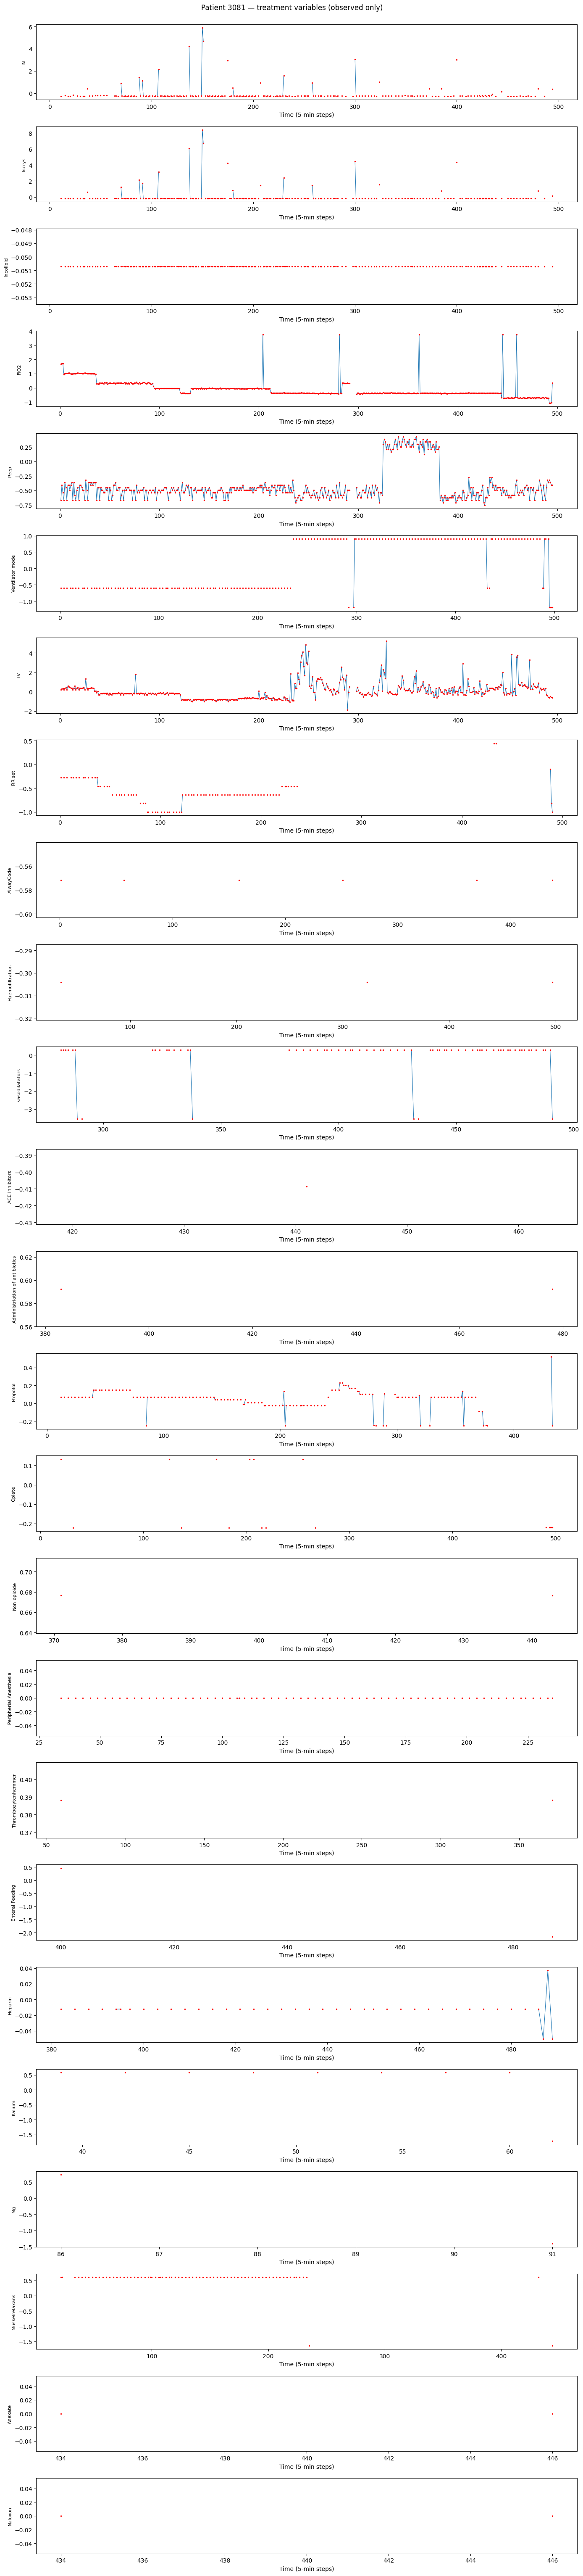

In [32]:
Plot_Patient_Timeline(0)

Patient 32730 (index 23): 1882 timesteps
  IN                       :  555 obs,  555 nonzero, raw_mean=-0.0938
  norepinephrine           :   38 obs,   38 nonzero, raw_mean=0.0547
  epinephrine              :   70 obs,   70 nonzero, raw_mean=-0.0727
  dobutamine               :  162 obs,  162 nonzero, raw_mean=-0.0242
  Loop diuretics           :    9 obs,    9 nonzero, raw_mean=-0.1318
  Propofol                 :  210 obs,  210 nonzero, raw_mean=-0.1547
  Insulin Kurzwirksam      :  225 obs,  225 nonzero, raw_mean=-0.0516
  Heparin                  :  509 obs,  509 nonzero, raw_mean=0.0171


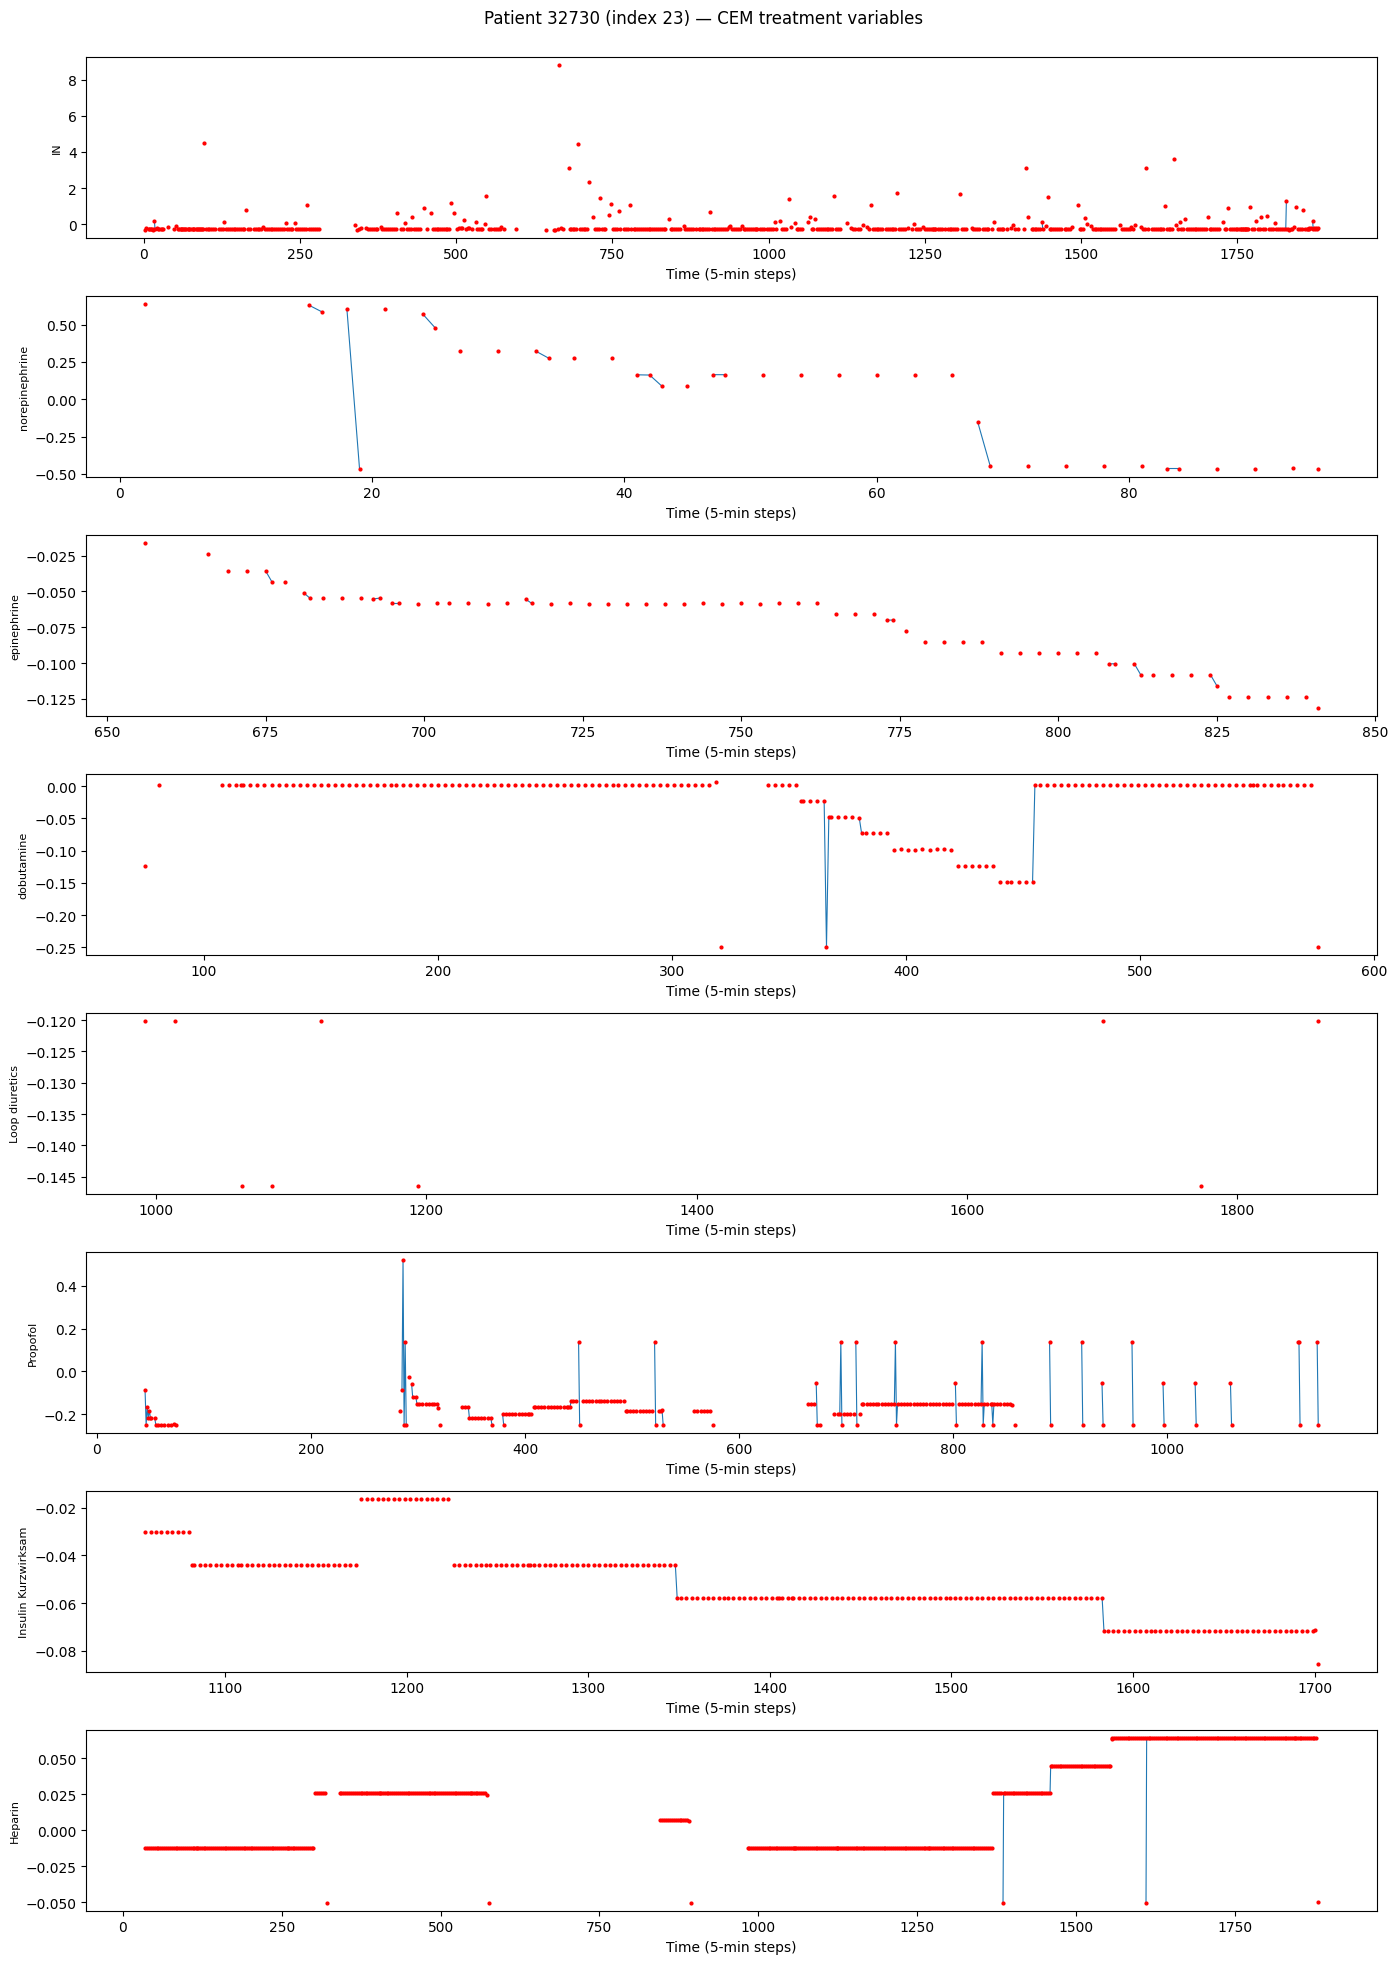

In [ ]:
import h5py, hdf5plugin
import numpy as np
import data.constants as constants
import matplotlib.pyplot as plt
from data.constants import CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES, TREATMENT_IDX

def Plot_Patient_CEM_Treatments(pid_target, split='test'):
    f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
    windows = f['windows'][split][:]

    # Find the patient by pid
    match = np.where(windows[:, 2] == pid_target)[0]
    if len(match) == 0:
        print(f"Patient {pid_target} not found in {split} split")
        f.close()
        return
    idx = match[0]
    start, end, pid = windows[idx]

    cem_global_idx = [TREATMENT_IDX[i] for i in CEM_TREATMENT_LOCAL_IDX]

    patient_data = f['data'][split][start:end][:, cem_global_idx]
    patient_mask = f['mask'][split][start:end][:, cem_global_idx]
    f.close()

    plot_data = patient_data.copy().astype(float)
    plot_data[patient_mask == 0] = np.nan

    print(f"Patient {pid} (index {idx}): {end-start} timesteps")
    for i, name in enumerate(CEM_TREATMENT_NAMES):
        n_obs = (patient_mask[:, i] == 1).sum()
        nonzero = patient_data[:, i][patient_mask[:, i] == 1]
        nonzero = nonzero[nonzero != 0]
        print(f"  {name:25s}: {n_obs:4d} obs, {len(nonzero):4d} nonzero, "
              f"raw_mean={patient_data[:, i][patient_mask[:, i]==1].mean() if n_obs>0 else float('nan'):.4f}")

    n_vars = len(CEM_TREATMENT_NAMES)
    fig, axes = plt.subplots(n_vars, 1, figsize=(14, max(2, 2.5 * n_vars)))

    for i, name in enumerate(CEM_TREATMENT_NAMES):
        axes[i].plot(plot_data[:, i], linewidth=0.8)
        axes[i].set_ylabel(name, fontsize=8)
        axes[i].set_xlabel("Time (5-min steps)")
        obs_times = np.where(~np.isnan(plot_data[:, i]))[0]
        axes[i].scatter(obs_times, plot_data[obs_times, i],
                        s=4, color='red', zorder=5)

    plt.suptitle(f"Patient {pid} (index {idx}) — CEM treatment variables")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

Plot_Patient_CEM_Treatments(16339, split='test')

# Evaluation

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py, hdf5plugin
from scipy import stats
from data.constants import MEASUREMENT_IDX

# Load results
with open('/home/bbe9928/thesis_work/hirid_jepa/results/gru_ctx36_tgt36_h128_l1_01_06_12-09_eval.json') as f:
    results = json.load(f)

# Build dataframe
df = pd.DataFrame(results['per_variable'])
df = df.dropna(subset=['improvement_pct'])
df = df.sort_values('improvement_pct', ascending=False).reset_index(drop=True)

# Load observation rates and stds from the scaled dataset
h5 = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
columns = [c.decode('utf-8') for c in h5['columns'][:]]

# Compute obs rate and std per measurement variable from train data
# Sample first 500k rows for speed
sample_data = h5['data']['train'][:500000]
sample_mask = h5['mask']['train'][:500000]

active_global_idx = [MEASUREMENT_IDX[i] for i in range(len(MEASUREMENT_IDX))]
measurement_names = [columns[i] for i in active_global_idx]

obs_rates = (sample_mask[:, active_global_idx] == 1).mean(axis=0)
# Std only over observed values
stds = np.array([
    sample_data[:, idx][sample_mask[:, idx] == 1].std()
    if (sample_mask[:, idx] == 1).sum() > 0 else 0.0
    for idx in active_global_idx
])

h5.close()

# Add obs_rate and std to df by matching variable names
obs_rate_dict = dict(zip(measurement_names, obs_rates))
std_dict      = dict(zip(measurement_names, stds))
df['obs_rate'] = df['name'].map(obs_rate_dict)
df['std']      = df['name'].map(std_dict)

# Statistical significance — bootstrap confidence interval on improvement
# For each variable, we have n_observations paired predictions
# Use normal approximation: se = std(error_diff) / sqrt(n)
# improvement is significant if CI doesn't include 0
df['significant'] = False
for idx, row in df.iterrows():
    # Approximate: if |improvement| > 2 * se, significant at 95%
    # se ≈ 1/sqrt(n) for normalized differences
    n = row['n_observations']
    se = 1.0 / np.sqrt(n) * 100  # rough SE of improvement %
    if abs(row['improvement_pct']) > 2 * se:
        df.loc[idx, 'significant'] = True

print(f"Significant improvements: {df[df['improvement_pct'] > 0]['significant'].sum()} / {(df['improvement_pct'] > 0).sum()}")
print(f"Significant declines:     {df[df['improvement_pct'] < 0]['significant'].sum()} / {(df['improvement_pct'] < 0).sum()}")

Significant improvements: 53 / 62
Significant declines:     15 / 20


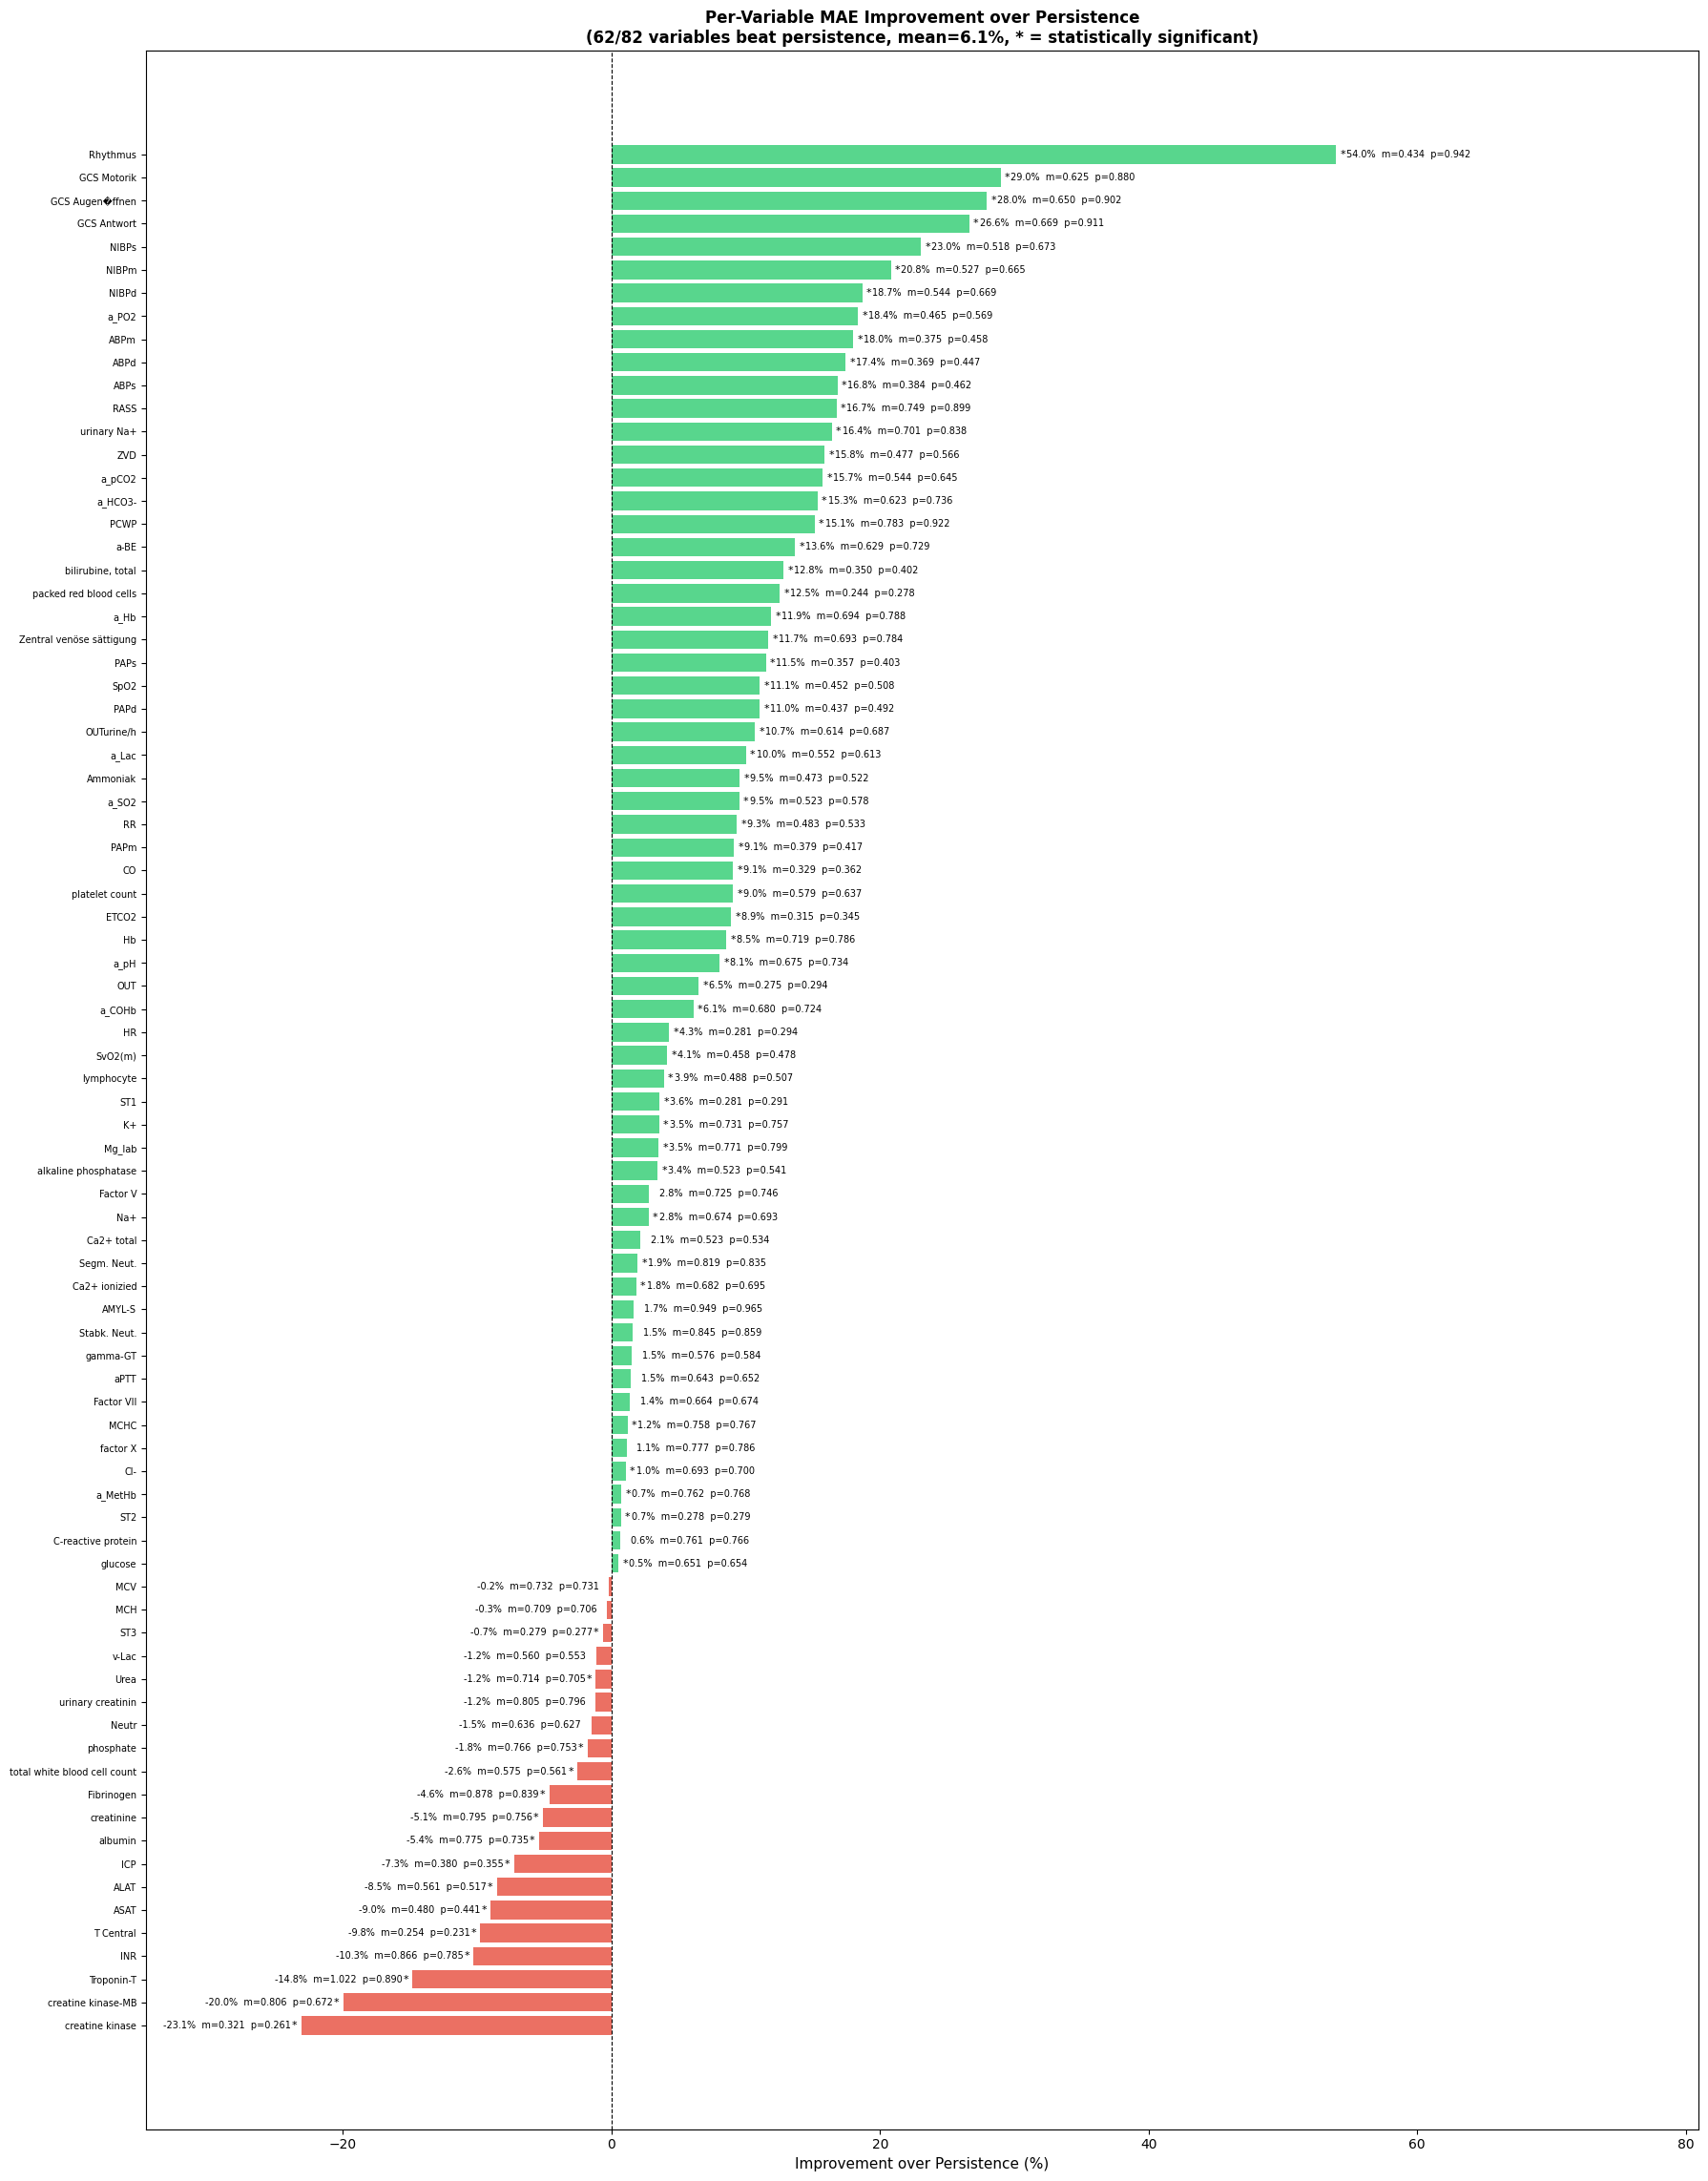

In [14]:
fig, ax = plt.subplots(figsize=(18, max(10, len(df) * 0.28)))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df['improvement_pct']]
ax.barh(range(len(df)), df['improvement_pct'], color=colors, alpha=0.8)

# Find x axis range to set consistent offset
x_max = df['improvement_pct'].max()
x_min = df['improvement_pct'].min()
offset = (x_max - x_min) * 0.01  # small offset past bar end

for i, (_, row) in enumerate(df.iterrows()):
    if row['significant']:
        ax.text(row['improvement_pct'] + (0.5 if row['improvement_pct'] >= 0 else -0.5),
                i, '*', ha='center', va='center', fontsize=8, color='black')

    label = f"{row['improvement_pct']:.1f}%  m={row['model_mae']:.3f}  p={row['persistence_mae']:.3f}"
    # Always place to the right of bar end
    x_pos = row['improvement_pct'] + offset if row['improvement_pct'] >= 0 else row['improvement_pct'] - offset
    ha    = 'left' if row['improvement_pct'] >= 0 else 'right'
    ax.text(x_pos, i, label, ha=ha, va='center',
            fontsize=7, color='black')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['name'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Improvement over Persistence (%)', fontsize=11)
ax.set_title(f'Per-Variable MAE Improvement over Persistence\n'
             f'({(df["improvement_pct"]>0).sum()}/{len(df)} variables beat persistence, '
             f'mean={df["improvement_pct"].mean():.1f}%, * = statistically significant)',
             fontsize=12, fontweight='bold')

# Extend x limits to make room for text
ax.set_xlim(x_min - abs(x_min) * 0.5, x_max + abs(x_max) * 0.5)

plt.tight_layout()
plt.show()

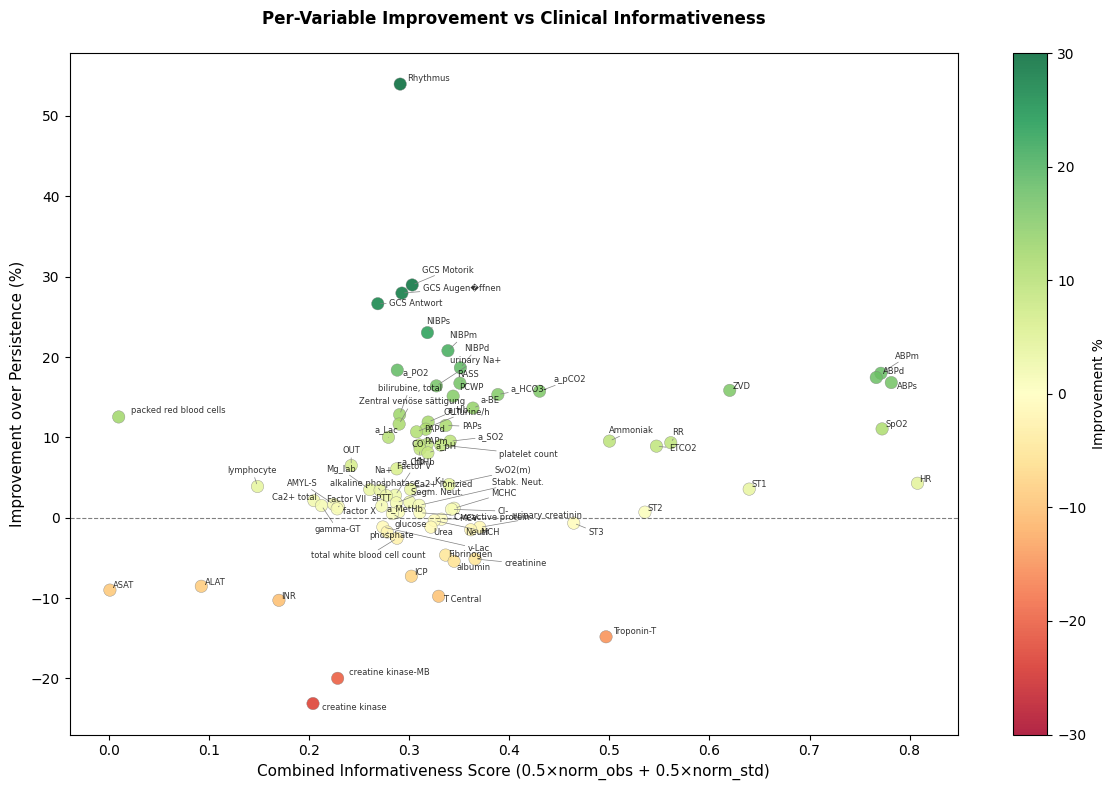

In [10]:
# Standalone combined score plot
fig, ax = plt.subplots(figsize=(12, 8))

# Use sum instead of product — gives credit for being good on either dimension
norm_obs = (obs - obs.min()) / (obs.max() - obs.min() + 1e-8)
norm_std = (std - std.min()) / (std.max() - std.min() + 1e-8)
combined = 0.5 * norm_obs + 0.5 * norm_std  # sum spreads values out
df['combined_score'] = combined

sc = ax.scatter(combined, df['improvement_pct'],
                c=df['improvement_pct'], cmap='RdYlGn',
                vmin=-30, vmax=30, s=80, alpha=0.85, edgecolors='grey', linewidths=0.3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Combined Informativeness Score (0.5×norm_obs + 0.5×norm_std)', fontsize=11)
ax.set_ylabel('Improvement over Persistence (%)', fontsize=11)
ax.set_title('Per-Variable Improvement vs Clinical Informativeness\n',
             fontsize=12, fontweight='bold')
plt.colorbar(sc, ax=ax, label='Improvement %')

# Label ALL variables with small font, with smart positioning to reduce overlap
from adjustText import adjust_text
texts = []
for _, row in df.iterrows():
    texts.append(ax.text(row['combined_score'], row['improvement_pct'],
                         row['name'], fontsize=6, alpha=0.8))

try:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
except ImportError:
    pass  # adjustText not installed, labels may overlap

plt.tight_layout()
plt.savefig('/home/bbe9928/thesis_work/hirid_jepa/results/combined_score_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()

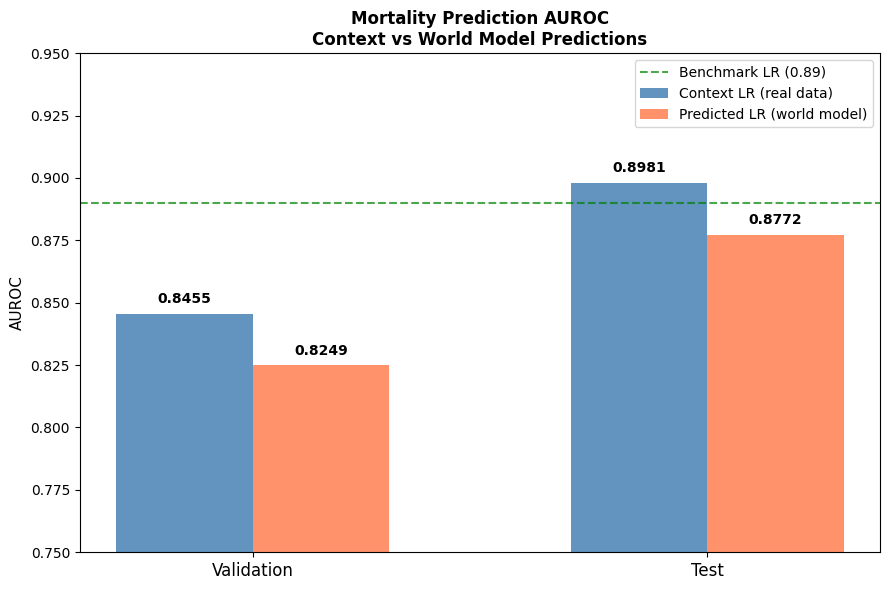

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(2)  # val and test
w = 0.3

val_aurocs  = [0.8455, 0.8249]
test_aurocs = [0.8981, 0.8772]

bars1 = ax.bar(x - w/2, [val_aurocs[0],  test_aurocs[0]], w,
               label='Context LR (real data)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, [val_aurocs[1],  test_aurocs[1]], w,
               label='Predicted LR (world model)', color='coral', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(0.89, color='green', linestyle='--', alpha=0.7, label='Benchmark LR (0.89)')

ax.set_xticks(x)
ax.set_xticklabels(['Validation', 'Test'], fontsize=12)
ax.set_ylabel('AUROC', fontsize=11)
ax.set_ylim(0.75, 0.95)
ax.set_title('Mortality Prediction AUROC\nContext vs World Model Predictions',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/home/bbe9928/thesis_work/hirid_jepa/results/world_model_mortality_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Grid Search

In [2]:
import json
import glob
import pandas as pd

results_dir = '/home/bbe9928/thesis_work/hirid_jepa/results/grid_search_*'
all_files   = glob.glob(f"{results_dir}/*_eval.json")

rows = []
for fpath in all_files:
    with open(fpath) as f:
        r = json.load(f)
    rows.append({
        'hidden_dim':      r['config']['hidden_dim'],
        'dropout':         r['config']['dropout'],
        'weight_decay':    r['config'].get('weight_decay', 1e-4),
        'n_beating':       r['summary']['n_beating_persistence'],
        'overall_mae':     r['summary']['overall_model_mae'],
        'pers_mae':        r['summary']['overall_persistence_mae'],
        'mean_improvement': r['summary']['mean_improvement'],
    })

df = pd.DataFrame(rows).sort_values('mean_improvement', ascending=False)
print(df.to_string())

   hidden_dim  dropout  weight_decay  n_beating  overall_mae  pers_mae  mean_improvement
4         128      0.3        0.0001         51     0.618110  0.629508          0.422361
5         128      0.4        0.0001         51     0.619126  0.629508          0.247391
7         256      0.4        0.0001         51     0.618654  0.629508         -0.313249
6         256      0.3        0.0001         52     0.621102  0.629508         -0.482417
3         256      0.4        0.0010         34     0.657168  0.629508         -7.752366
2         256      0.3        0.0010         36     0.657175  0.629508         -7.806724
0         128      0.3        0.0010         31     0.657058  0.629508         -7.812298
1         128      0.4        0.0010         34     0.657952  0.629508         -8.108414


## Subset Creation

In [12]:
import h5py, hdf5plugin
import numpy as np

f_new = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
f_ml  = h5py.File('/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/ml_stage/ml_stage_12h.h5', 'r')

tasks        = [t.decode('utf-8') for t in f_ml['labels']['tasks'][:]]
apache_idx   = tasks.index('Phenotyping_APACHEGroup')

apache_names = {
    1: 'Cardiovascular', 2: 'Pulmonary', 3: 'Gastrointestinal',
    4: 'Neurological', 6: 'Sepsis_Other', 7: 'Trauma',
    8: 'Metabolic_Endocrinology', 9: 'Hematology',
    11: 'Surgical_Cardiovascular', 12: 'Surgical_Respiratory',
    13: 'Surgical_Gastrointestinal', 14: 'Surgical_Neurological',
    15: 'Surgical_Trauma', 16: 'Surgical_Urogenital',
    17: 'Surgical_Gynecology_Orthopedics'
}

def get_apache_label_per_patient(split, f_ml):
    """Returns dict of {pid: apache_label} for patients with a single apache label."""
    apache_col  = f_ml['labels'][split][:, apache_idx]
    windows     = f_ml['patient_windows'][split][:]
    pid_to_apache = {}
    for start, end, pid in windows:
        labels = apache_col[start:end]
        labels = labels[~np.isnan(labels)]
        unique = np.unique(labels)
        if len(unique) == 1:
            pid_to_apache[int(pid)] = int(unique[0])
    return pid_to_apache

def create_common_stage_subset(apache_group, f_new, f_ml, output_dir):
    group_name  = apache_names[apache_group].replace('/', '_')
    output_path = f"{output_dir}/{group_name}_common_subset.h5"
    print(f"Creating subset for: {group_name}")

    with h5py.File(output_path, 'w') as f_out:
        # Copy columns
        f_out.create_dataset('columns', data=f_new['columns'][:])

        for split in ['train', 'val', 'test']:
            pid_to_apache = get_apache_label_per_patient(split, f_ml)
            target_pids   = {pid for pid, label in pid_to_apache.items()
                             if label == apache_group}

            windows     = f_new['windows'][split][:]
            data_full   = f_new['data'][split]
            mask_full   = f_new['mask'][split]
            delta_full = f_new['delta_t'][split]

            selected_data    = []
            selected_masks   = []
            selected_windows = []
            selected_deltas = []
            new_start        = 0

            for start, end, pid in windows:
                if int(pid) not in target_pids:
                    continue
                n_rows = end - start
                selected_data.append(data_full[start:end])
                selected_masks.append(mask_full[start:end])
                selected_windows.append([new_start, new_start + n_rows, pid])
                selected_deltas.append(delta_full[start:end])
                new_start += n_rows

            if not selected_data:
                print(f"  {split}: 0 patients — skipping")
                continue

            data_arr    = np.concatenate(selected_data,  axis=0).astype(np.float32)
            mask_arr    = np.concatenate(selected_masks, axis=0).astype(np.float32)
            windows_arr = np.array(selected_windows, dtype=np.int64)
            delta_arr = np.concatenate(selected_deltas, axis=0).astype(np.float32)
            f_out.create_dataset(f'delta_t/{split}', data=delta_arr, compression='lzf')
            f_out.create_dataset(f'data/{split}',    data=data_arr,    compression='lzf')
            f_out.create_dataset(f'mask/{split}',    data=mask_arr,    compression='lzf')
            f_out.create_dataset(f'windows/{split}', data=windows_arr)

            print(f"  {split}: {len(selected_windows)} patients, {new_start} timesteps")

        # Copy scaling stats from original
        for key in f_new.attrs:
            f_out.attrs[key] = f_new.attrs[key]

    print(f"  Saved to {output_path}\n")
    return output_path

output_dir = '/home/bbe9928/thesis_work/hirid_jepa/data'

# Extract cardiovascular (1) and surgical neurological (14)
create_common_stage_subset(1,  f_new, f_ml, output_dir)
create_common_stage_subset(14, f_new, f_ml, output_dir)

f_new.close()
f_ml.close()

Creating subset for: Cardiovascular
  train: 1703 patients, 1765089 timesteps
  val: 309 patients, 339749 timesteps
  test: 355 patients, 357182 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5

Creating subset for: Surgical_Neurological
  train: 778 patients, 1002324 timesteps
  val: 174 patients, 226979 timesteps
  test: 154 patients, 217388 timesteps
  Saved to /home/bbe9928/thesis_work/hirid_jepa/data/Surgical_Neurological_common_subset.h5



In [5]:
import h5py, hdf5plugin

f_new = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')

def print_tree(name, obj):
    depth = name.count('/')
    indent = '  ' * depth
    if isinstance(obj, h5py.Dataset):
        print(f"{indent}{name.split('/')[-1]}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"{indent}{name.split('/')[-1]}/")

print("File structure:")
f_new.visititems(print_tree)
f_new.close()

File structure:
columns: shape=(202,), dtype=|S30
data/
  test: shape=(3253059, 202), dtype=float32
  train: shape=(15513124, 202), dtype=float32
  val: shape=(3299634, 202), dtype=float32
delta_t/
  test: shape=(3253059, 202), dtype=float32
  train: shape=(15513124, 202), dtype=float32
  val: shape=(3299634, 202), dtype=float32
mask/
  test: shape=(3253059, 202), dtype=float32
  train: shape=(15513124, 202), dtype=float32
  val: shape=(3299634, 202), dtype=float32
windows/
  test: shape=(5086, 3), dtype=int64
  train: shape=(23727, 3), dtype=int64
  val: shape=(5085, 3), dtype=int64


## Statistically Significant Variables

In [16]:
import numpy as np
import h5py
import hdf5plugin
import matplotlib.pyplot as plt
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
all_columns       = [c.decode('utf-8') for c in f['columns'][:]]
measurement_names = [all_columns[i] for i in MEASUREMENT_IDX]
treatment_names   = [all_columns[i] for i in TREATMENT_IDX]

def compute_stats(data, mask, names, windows):
    n_vars      = len(names)
    all_stds    = []
    all_obs_rates = []

    for local_idx in range(n_vars):
        var_stds     = []
        var_obs_rates = []

        for start, end, pid in windows:
            patient      = data[start:end, local_idx]
            patient_mask = mask[start:end, local_idx]
            observed     = patient[patient_mask == 1]
            n_total      = end - start

            var_obs_rates.append(len(observed) / n_total if n_total > 0 else 0.0)

            if len(observed) < 2:
                continue
            var_stds.append(np.std(observed))

        all_stds.append(np.mean(var_stds) if var_stds else 0.0)
        all_obs_rates.append(np.mean(var_obs_rates))

    return np.array(all_stds), np.array(all_obs_rates)

train_windows = f['windows']['train'][:]
train_mask    = f['mask']['train']

# Measurements
m_data_full = f['data']['train'][:, MEASUREMENT_IDX]
m_mask_full = train_mask[:, MEASUREMENT_IDX]

# Treatments
t_data_full = f['data']['train'][:, TREATMENT_IDX]
t_mask_full = train_mask[:, TREATMENT_IDX]

m_stds, m_obs_rates = compute_stats(m_data_full, m_mask_full, measurement_names, train_windows)
t_stds, t_obs_rates = compute_stats(t_data_full, t_mask_full, treatment_names, train_windows)

f.close()

In [ ]:
def plot_stats(names, stds, obs_rates, title_prefix):
    cutoff = 0.3
    TOP_X  = 14

    # Replace NaN with 0 before plotting
    stds      = np.nan_to_num(stds,      nan=0.0)
    obs_rates = np.nan_to_num(obs_rates, nan=0.0)

    # Combined score
    norm_std = (stds      - stds.min())      / (stds.max()      - stds.min()      + 1e-8)
    norm_obs = (obs_rates - obs_rates.min()) / (obs_rates.max() - obs_rates.min() + 1e-8)
    combined = norm_std * norm_obs
    combined = np.nan_to_num(combined, nan=0.0)

    fig, axes = plt.subplots(1, 3, figsize=(36, max(4, len(names) * 0.3)))
    plt.subplots_adjust(left=0.08, right=0.98, wspace=0.5)

    # --- Plot 1: Standard Deviation ---
    sorted_idx = np.argsort(stds)[::-1]
    axes[0].barh([names[i] for i in sorted_idx], stds[sorted_idx], color='steelblue')
    axes[0].set_xlabel('Mean Std Dev (observed values only)')
    axes[0].set_title(f'{title_prefix} — Standard Deviation')
    axes[0].invert_yaxis()
    axes[0].tick_params(axis='y', labelsize=7)

    # --- Plot 2: Observation Rate ---
    sorted_idx = np.argsort(obs_rates)[::-1]
    axes[1].barh([names[i] for i in sorted_idx], obs_rates[sorted_idx], color='coral')
    axes[1].set_xlabel('Observation Rate')
    axes[1].set_title(f'{title_prefix} — Observation Rate')
    axes[1].invert_yaxis()
    axes[1].tick_params(axis='y', labelsize=7)

    # --- Plot 3: Combined Score ---
    sorted_idx = np.argsort(combined)[::-1]
    axes[2].barh([names[i] for i in sorted_idx], combined[sorted_idx], color='mediumpurple')
    axes[2].set_xlabel('Combined Score (norm_std × norm_obs_rate)')
    axes[2].set_title(f'{title_prefix} — Combined Score')
    axes[2].invert_yaxis()
    axes[2].tick_params(axis='y', labelsize=7)
    axes[2].set_xlim(0, max(combined.max() * 1.1, 0.1))
    axes[2].axvline(x=cutoff, color='red', linestyle='--', label=f'Cutoff ({cutoff})')
    axes[2].legend()

    #plt.savefig(f'{title_prefix}_stats.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Print above cutoff
    selected = [(names[i], i, combined[i]) for i in range(len(names)) if combined[i] >= cutoff]
    selected.sort(key=lambda x: x[2], reverse=True)
    print(f"\n{title_prefix} — {len(selected)} variables above cutoff {cutoff}:")
    for name, idx, score in selected:
        print(f"  {idx:3d} {name:40s} score={score:.4f}")

    # Print top X
    print(f"\n{title_prefix} — Top {TOP_X}:")
    top_idx = np.argsort(combined)[::-1][:TOP_X]
    for i in top_idx:
        print(f"  {i:3d} {names[i]:40s} score={combined[i]:.4f}")

    label = "INFORMATIVE_MEASUREMENT_IDX" if "Measurement" in title_prefix else "INFORMATIVE_TREATMENT_IDX"
    print(f"\n{label} = {sorted(top_idx.tolist())}")

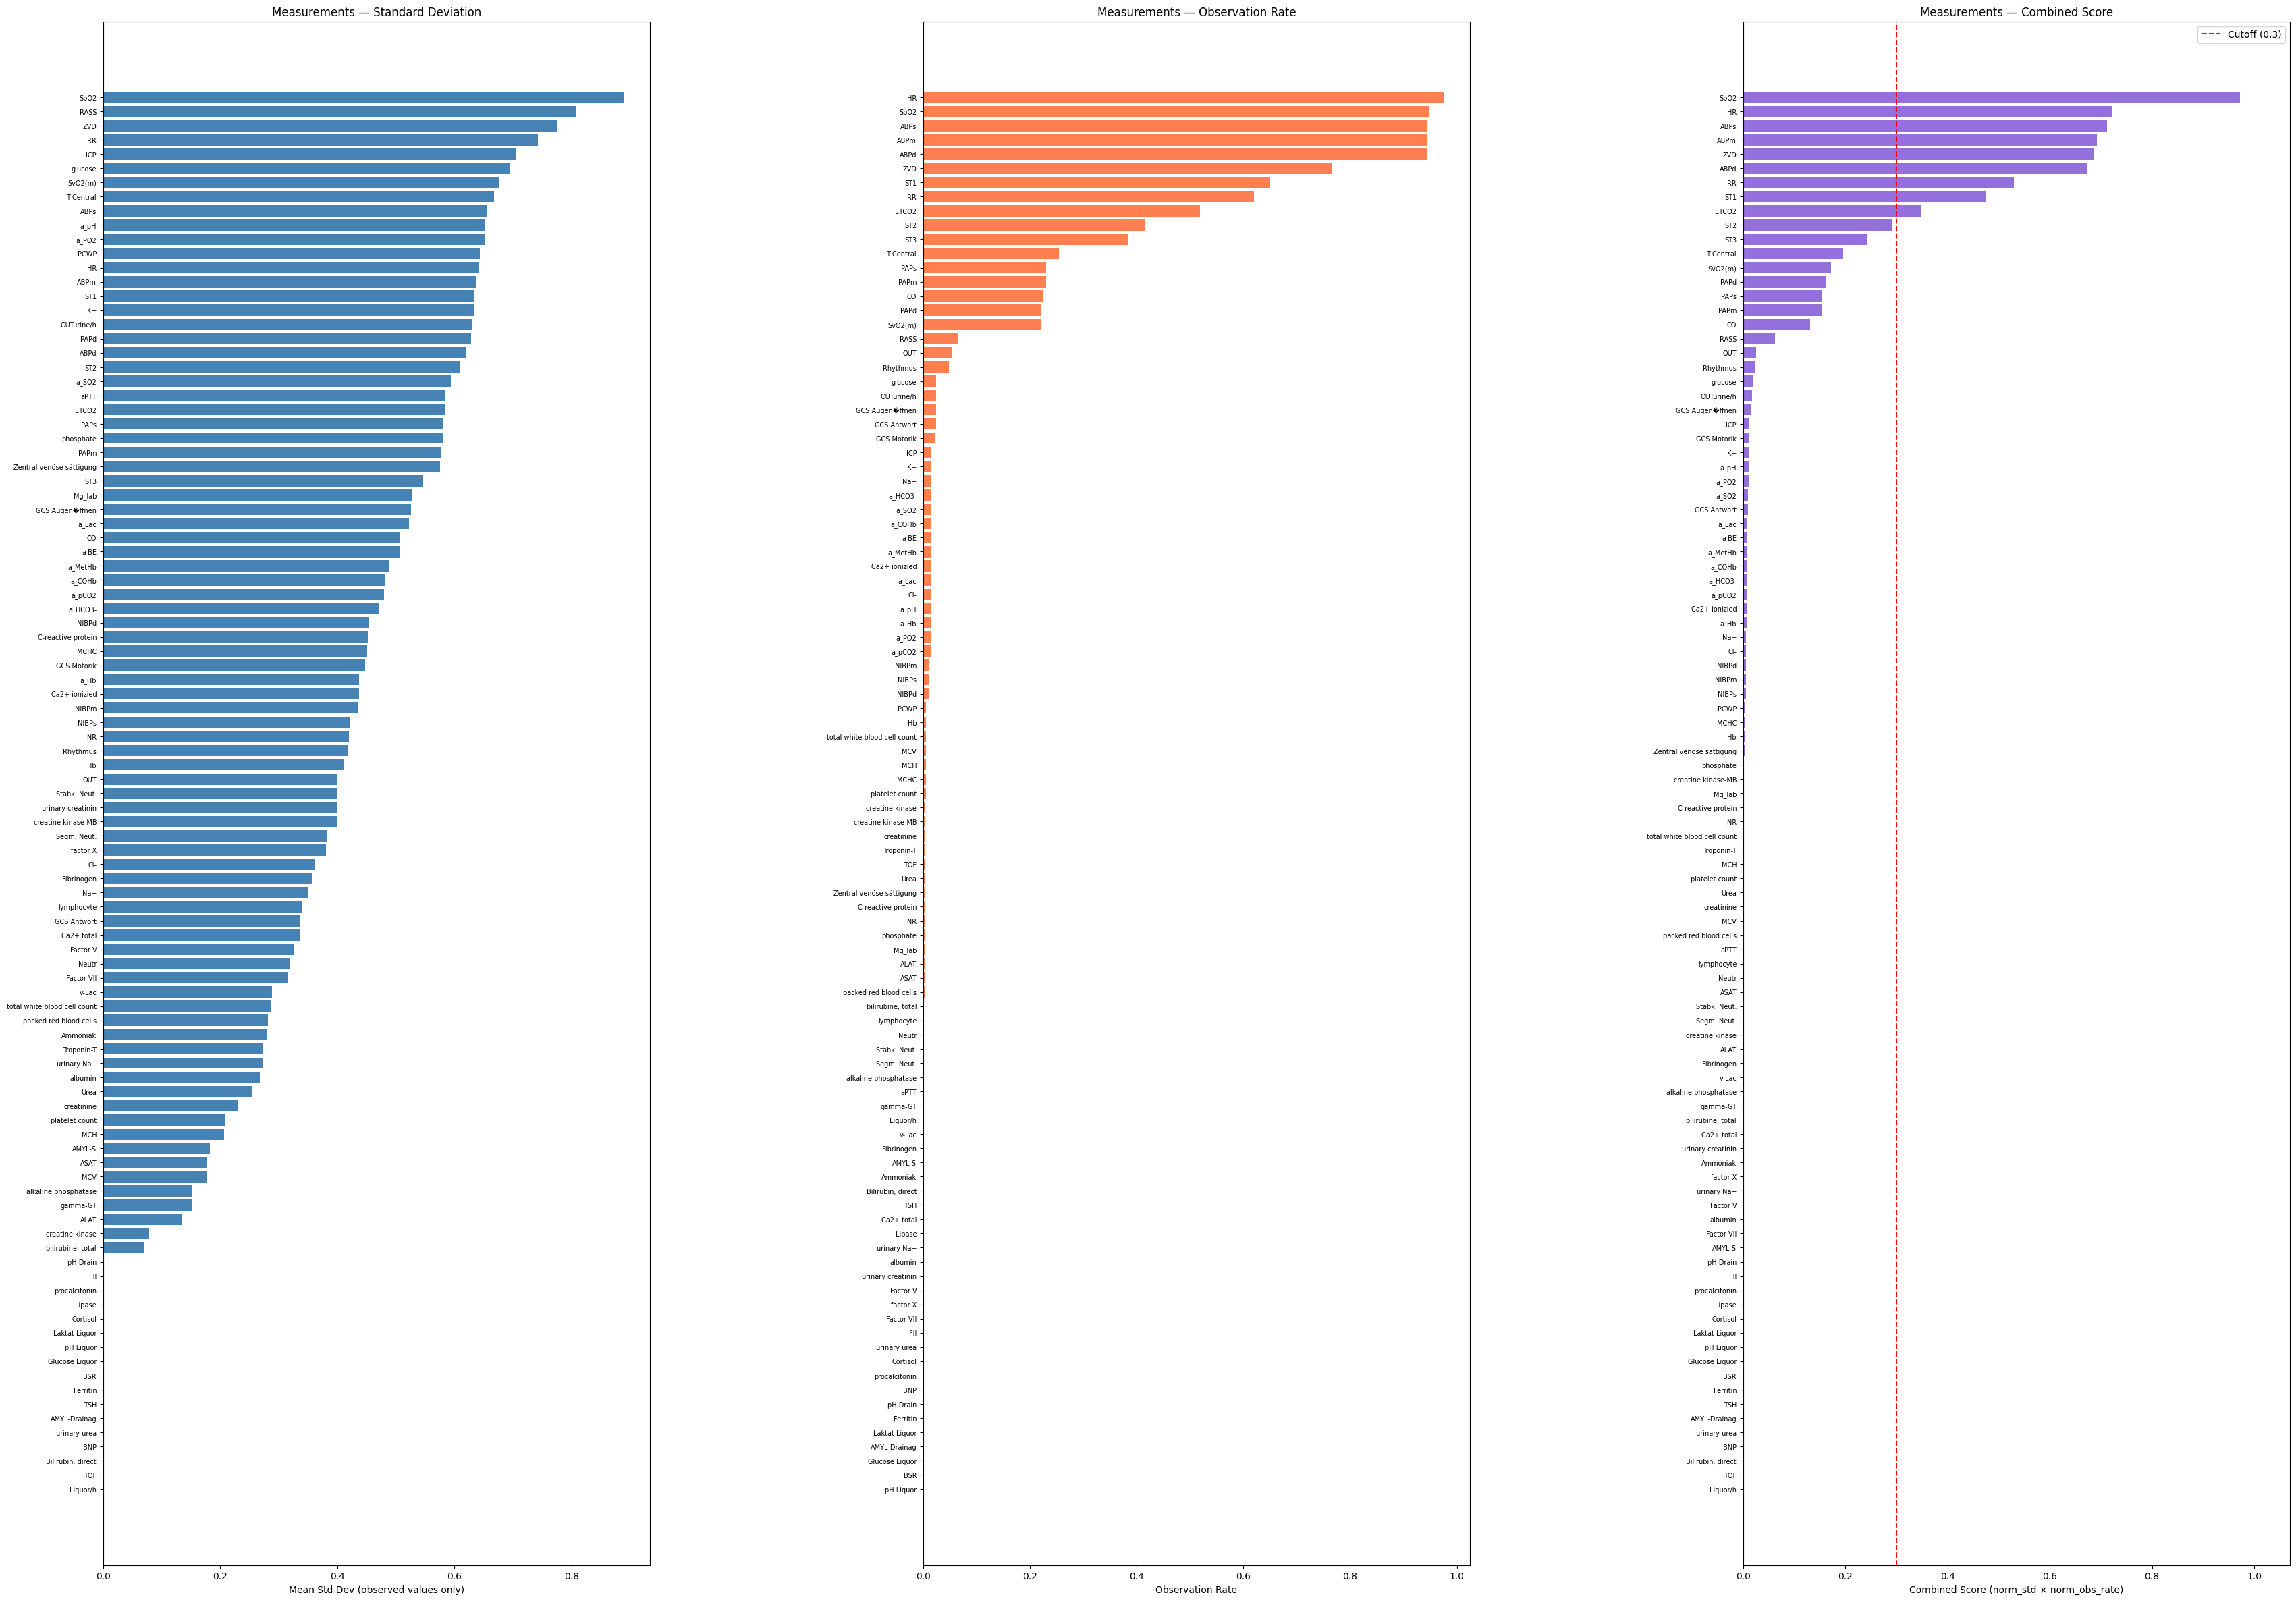


Measurements — 9 variables above cutoff 0.3:
   19 SpO2                                     score=0.9725
    0 HR                                       score=0.7217
    2 ABPs                                     score=0.7121
    4 ABPm                                     score=0.6925
   14 ZVD                                      score=0.6852
    3 ABPd                                     score=0.6742
   21 RR                                       score=0.5301
   15 ST1                                      score=0.4755
   20 ETCO2                                    score=0.3487

Measurements — Top 14:
   19 SpO2                                     score=0.9725
    0 HR                                       score=0.7217
    2 ABPs                                     score=0.7121
    4 ABPm                                     score=0.6925
   14 ZVD                                      score=0.6852
    3 ABPd                                     score=0.6742
   21 RR                      

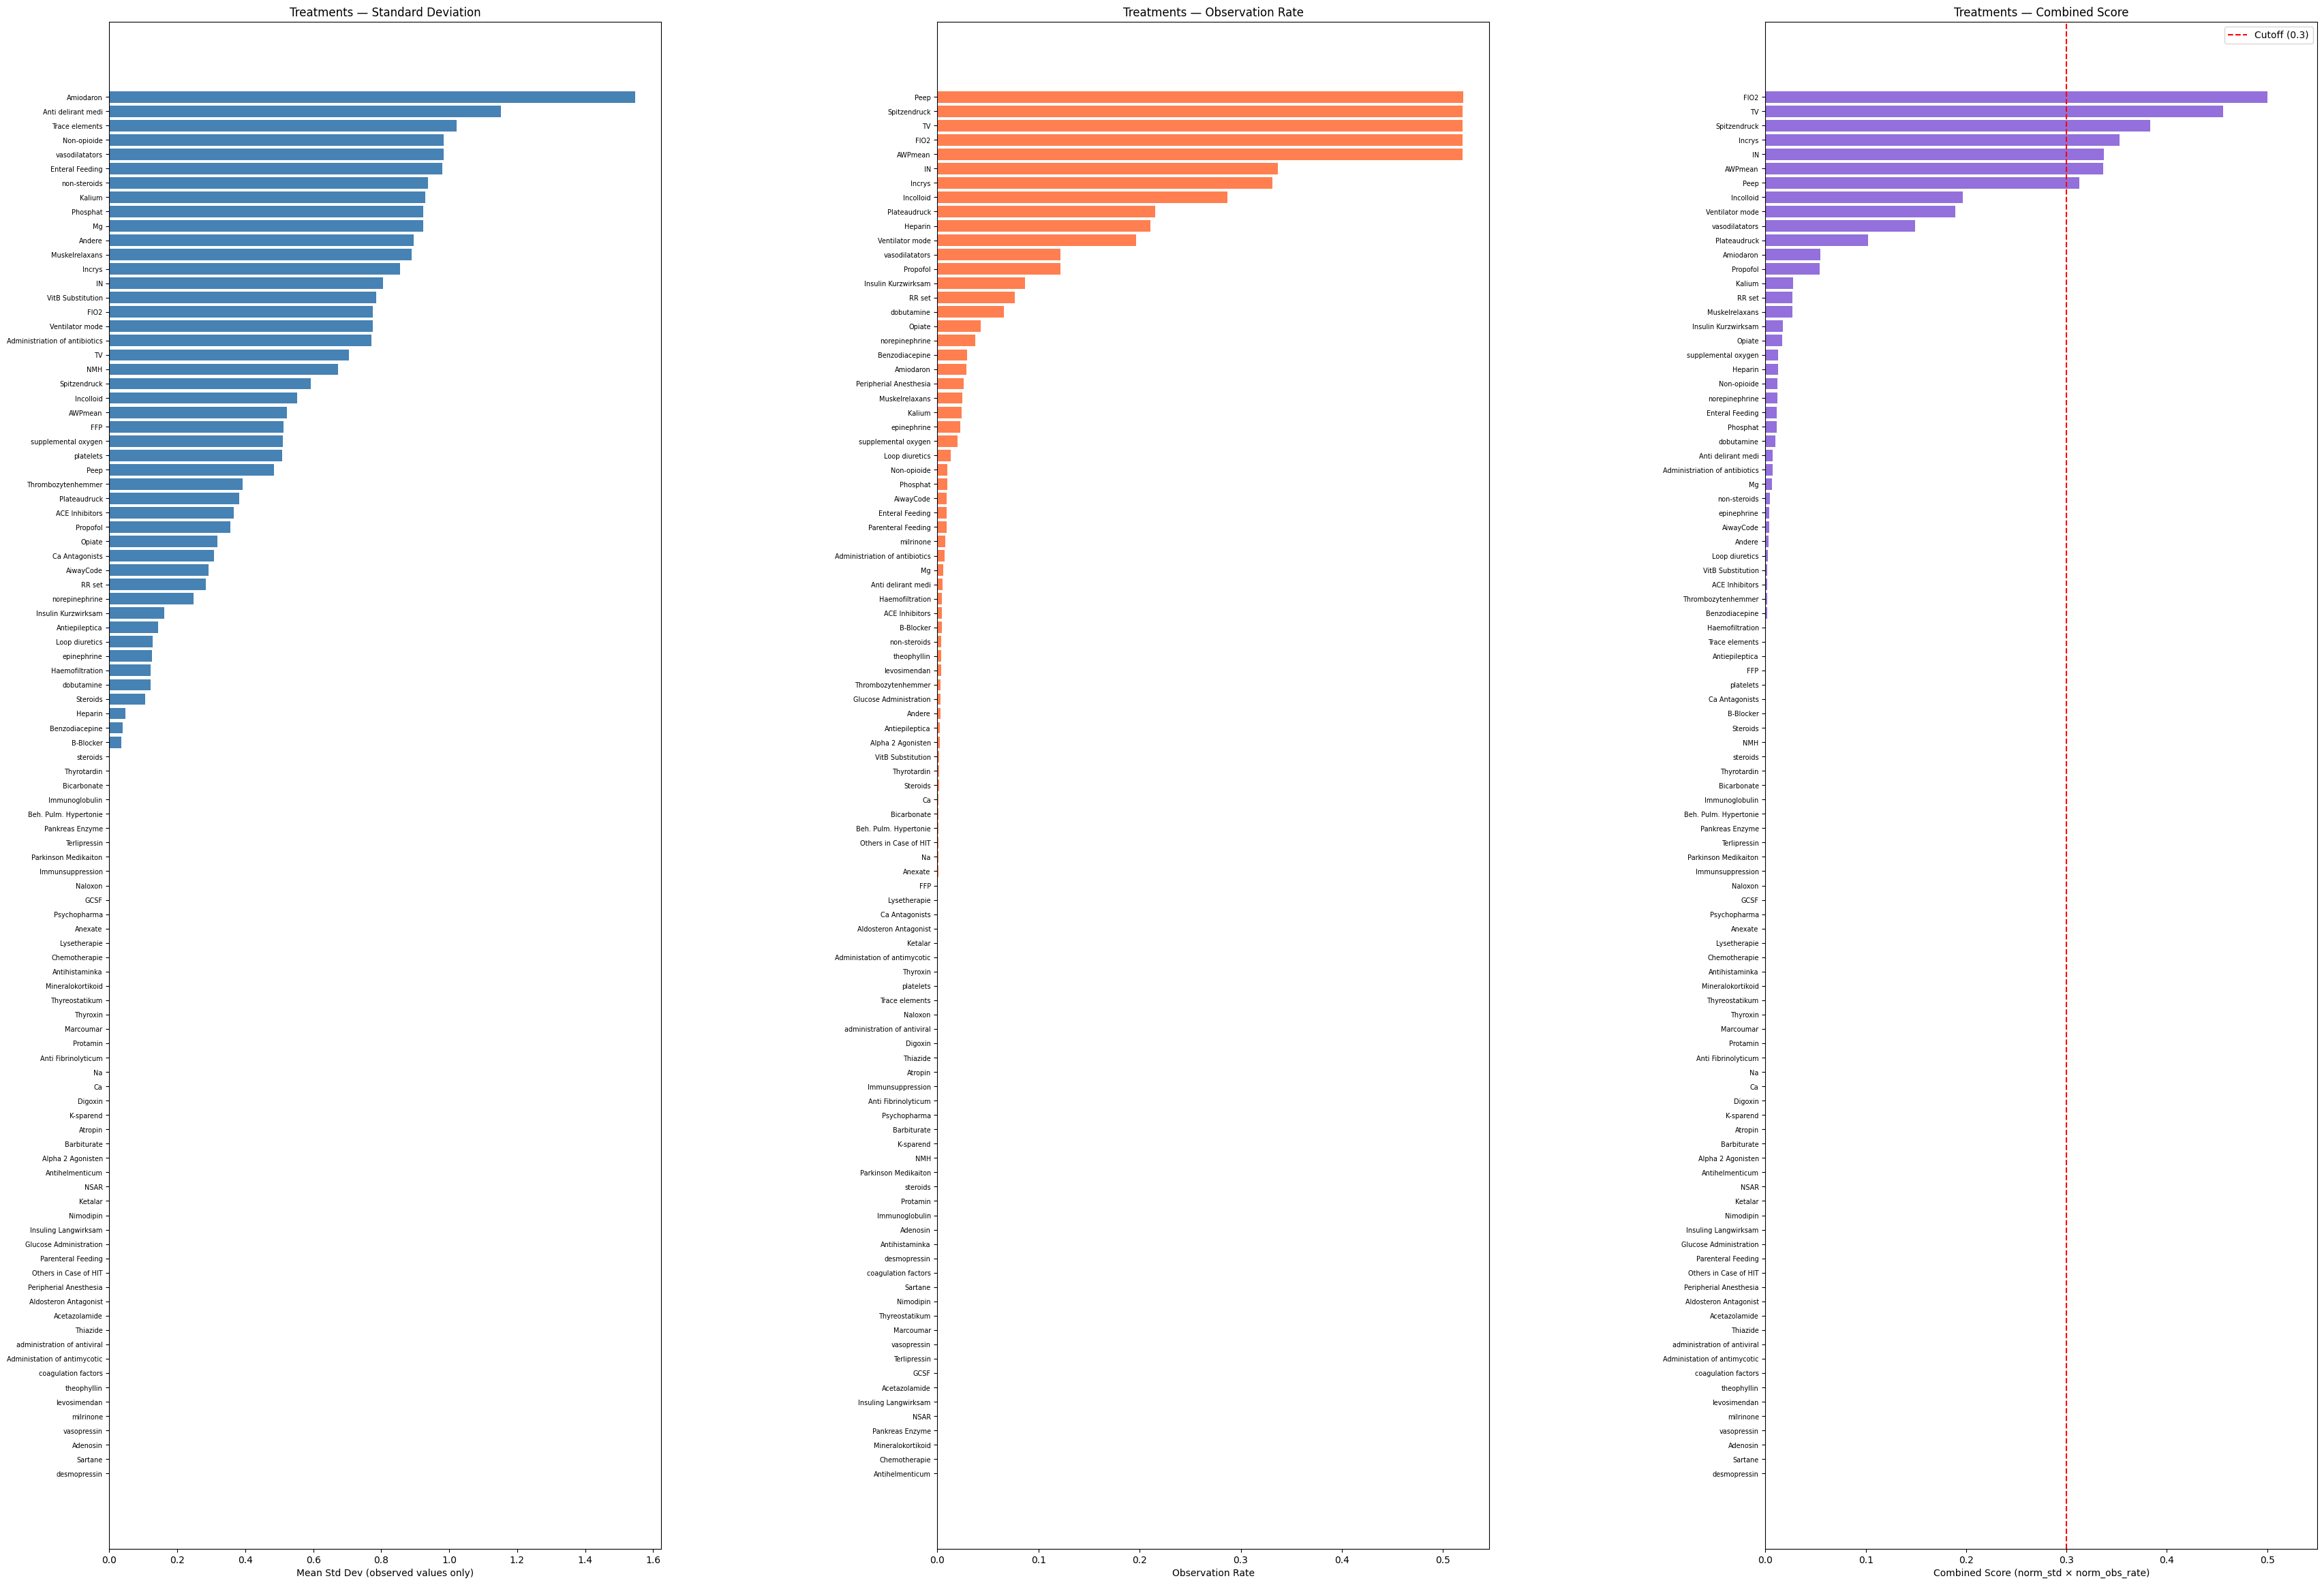


Treatments — 7 variables above cutoff 0.3:
    4 FIO2                                     score=0.5001
    7 TV                                       score=0.4557
    8 Spitzendruck                             score=0.3833
    2 Incrys                                   score=0.3530
    1 IN                                       score=0.3369
   10 AWPmean                                  score=0.3368
    5 Peep                                     score=0.3129

Treatments — Top 14:
    4 FIO2                                     score=0.5001
    7 TV                                       score=0.4557
    8 Spitzendruck                             score=0.3833
    2 Incrys                                   score=0.3530
    1 IN                                       score=0.3369
   10 AWPmean                                  score=0.3368
    5 Peep                                     score=0.3129
    3 Incolloid                                score=0.1965
    6 Ventilator mode             

In [18]:
plot_stats(measurement_names, m_stds, m_obs_rates, "Measurements")
plot_stats(treatment_names,   t_stds, t_obs_rates, "Treatments")


## Significant Treatments for RL model

In [4]:
import h5py, hdf5plugin, json
import numpy as np
from data.constants import TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
treatment_names = [columns[i] for i in TREATMENT_IDX]

# Compute observation rate per treatment in training data
train_mask = f['mask']['train']
t_obs_rates = train_mask[:, TREATMENT_IDX].mean(axis=0)
f.close()

# Print sorted by observation rate
sorted_idx = np.argsort(t_obs_rates)[::-1]
print("Treatment variables by observation rate (cardiovascular patients):")
for i in sorted_idx[:30]:
    print(f"  {i:3d} {treatment_names[i]:40s} obs_rate={t_obs_rates[i]:.4f}")

Treatment variables by observation rate (cardiovascular patients):
    5 Peep                                     obs_rate=0.5736
    7 TV                                       obs_rate=0.5732
    8 Spitzendruck                             obs_rate=0.5729
   10 AWPmean                                  obs_rate=0.5725
    4 FIO2                                     obs_rate=0.5724
    1 IN                                       obs_rate=0.3349
    2 Incrys                                   obs_rate=0.3309
    3 Incolloid                                obs_rate=0.2804
   61 Heparin                                  obs_rate=0.2264
    6 Ventilator mode                          obs_rate=0.2037
    9 Plateaudruck                             obs_rate=0.1759
   25 vasodilatators                           obs_rate=0.1199
   47 Propofol                                 obs_rate=0.1177
   50 Insulin Kurzwirksam                      obs_rate=0.1149
   11 RR set                                   obs_

# Mortality Classifier

In [2]:
import h5py, hdf5plugin, json
import numpy as np

f_ml = h5py.File('/home/bbe9928/HIRID-ICU-Benchmark/real_data_wdir/ml_stage/ml_stage_12h.h5', 'r')

tasks         = [t.decode('utf-8') for t in f_ml['labels']['tasks'][:]]
mortality_idx = tasks.index('Mortality_At24Hours')

mortality_labels = {}

for split in ['train', 'val', 'test']:
    windows = f_ml['patient_windows'][split][:]
    labels  = f_ml['labels'][split][:, mortality_idx]

    split_labels = {}
    for start, end, pid in windows:
        patient_labels = labels[start:end]
        patient_labels = patient_labels[~np.isnan(patient_labels)]
        if len(patient_labels) > 0:
            split_labels[int(pid)] = int(patient_labels[0])

    mortality_labels[split] = split_labels
    n_total   = len(windows)
    n_labeled = len(split_labels)
    n_pos     = sum(v for v in split_labels.values())
    print(f"{split}: {n_labeled}/{n_total} patients with label ({n_labeled/n_total*100:.1f}% coverage), "
          f"{n_pos} died ({n_pos/n_labeled*100:.1f}%)")

f_ml.close()

with open('/home/bbe9928/thesis_work/hirid_jepa/data/mortality_labels.json', 'w') as f:
    json.dump(mortality_labels, f)
print("Saved mortality_labels.json")

train: 10524/23727 patients with label (44.4% coverage), 911 died (8.7%)
val: 2205/5085 patients with label (43.4% coverage), 157 died (7.1%)
test: 2231/5086 patients with label (43.9% coverage), 186 died (8.3%)
Saved mortality_labels.json


# Debugging

In [6]:
import h5py, hdf5plugin
from data.constants import DATETIME_IDX, DEMOGRAPHIC_IDX, MEASUREMENT_IDX, TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
f.close()

print("=== DATETIME ===")
for i in DATETIME_IDX:
    print(f"  [{i}] {columns[i]}")

print("\n=== DEMOGRAPHICS ===")
for i in DEMOGRAPHIC_IDX:
    print(f"  [{i}] {columns[i]}")

print("\n=== MEASUREMENTS (all) ===")
for local_i, global_i in enumerate(MEASUREMENT_IDX):
    print(f"  local={local_i:3d} global={global_i:3d} {columns[global_i]}")

print("\n=== TREATMENTS (all) ===")
for local_i, global_i in enumerate(TREATMENT_IDX):
    print(f"  local={local_i:3d} global={global_i:3d} {columns[global_i]}")

# Check overlaps
all_indices = DATETIME_IDX + DEMOGRAPHIC_IDX + MEASUREMENT_IDX + TREATMENT_IDX
duplicates = [i for i in set(all_indices) if all_indices.count(i) > 1]
print(f"\n=== OVERLAPS (should be empty) ===")
print(duplicates if duplicates else "None")

# Check unassigned
all_col_idx = set(range(len(columns)))
assigned    = set(all_indices)
unassigned  = all_col_idx - assigned
print(f"\n=== UNASSIGNED COLUMNS ===")
for i in sorted(unassigned):
    print(f"  [{i}] {columns[i]}")

=== DATETIME ===
  [0] datetime

=== DEMOGRAPHICS ===
  [46] Weight
  [198] admissiontime
  [199] age
  [200] sex
  [201] height

=== MEASUREMENTS (all) ===
  local=  0 global=  1 HR
  local=  1 global=  2 T Central
  local=  2 global=  3 ABPs
  local=  3 global=  4 ABPd
  local=  4 global=  5 ABPm
  local=  5 global=  6 NIBPs
  local=  6 global=  7 NIBPd
  local=  7 global=  8 NIBPm
  local=  8 global=  9 PAPm
  local=  9 global= 10 PAPs
  local= 10 global= 11 PAPd
  local= 11 global= 12 PCWP
  local= 12 global= 13 CO
  local= 13 global= 14 SvO2(m)
  local= 14 global= 15 ZVD
  local= 15 global= 16 ST1
  local= 16 global= 17 ST2
  local= 17 global= 18 ST3
  local= 18 global= 19 Rhythmus
  local= 19 global= 20 SpO2
  local= 20 global= 21 ETCO2
  local= 21 global= 22 RR
  local= 22 global= 24 OUTurine/h
  local= 23 global= 25 GCS Antwort
  local= 24 global= 26 GCS Motorik
  local= 25 global= 27 GCS Augen�ffnen
  local= 26 global= 28 RASS
  local= 27 global= 29 ICP
  local= 28 global= 30 

In [1]:
def compute_delta_t(mask_window):
    T, V = mask_window.shape
    delta = np.zeros((T, V), dtype=np.float32)

    for v in range(V):
        last_obs = -1
        for t in range(T):
            if mask_window[t, v] == 1:
                last_obs = t
                delta[t, v] = 0.0
            else:
                delta[t, v] = (t - last_obs) if last_obs >= 0 else (t + 1)

    return delta / T

In [2]:
import numpy as np

mask_window = [[1, 0, 1, 1, 0], [0, 0,0, 0, 1], [1, 1, 0, 1, 1]]
delta = compute_delta_t(np.array(mask_window))
print("Mask Window:\n", np.array(mask_window))
print("Delta T:\n", delta)

Mask Window:
 [[1 0 1 1 0]
 [0 0 0 0 1]
 [1 1 0 1 1]]
Delta T:
 [[0.         0.33333334 0.         0.         0.33333334]
 [0.33333334 0.6666667  0.33333334 0.33333334 0.        ]
 [0.         0.         0.6666667  0.         0.        ]]


In [ ]:
from data.dataset import HiRIDDataset, compute_delta_t
import numpy as np

# Load one sample
ds = HiRIDDataset(
    '/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5',
    'train', context_steps=36, target_steps=36
)
sample = ds[0]

mask  = sample['context_mask'].numpy()  # (36, n_measurements)
delta = sample['delta_t'].numpy()       # (36, n_measurements)

# Check variable 0 (HR — most frequently observed)
print("HR mask:   ", mask[:, 0])
print("HR delta_t:", delta[:, 0])
print()
# Check a sparse variable (pick one with many zeros in mask)
sparse_var = np.argmin(mask.mean(axis=0))
print(f"Sparse var index: {sparse_var}")
print("mask:   ", mask[:, sparse_var])
print("delta_t:", delta[:, sparse_var])

TypeError: HiRIDDataset.compute_delta_t() takes 1 positional argument but 2 were given

In [3]:
import config
from data.dataset import HiRIDDataset, compute_delta_t

ds = HiRIDDataset(config.DATA_PATH, 'test', config.CONTEXT_STEPS, config.TARGET_STEPS)
sample = ds[0]
print("HR delta_t:", sample['delta_t'][:, 0])  # assuming HR is index 0
print("HR mask:", sample['context_mask'][:, 0])
print("HR measurements:", sample['measurements'][:, 0])

Precomputing delta_t...
Done.
HR delta_t: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
HR mask: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
HR measurements: tensor([ 0.0235,  0.0235,  0.5241,  0.0791,  0.0235,  0.0235,  0.9135,  0.5241,
         0.8579,  0.8579,  0.7466,  0.7466,  0.5241,  0.6910,  0.5241,  0.4685,
         0.3016,  0.2460,  0.4129,  0.1348,  0.4129,  0.0791,  0.3016,  0.2460,
         0.1904, -0.0321, -0.0877,  0.1348, -0.1990, -0.1990, -0.1434, -0.3102,
        -0.3659, -0.5327, -0.5884, -0.6440])


In [4]:
import torch
ckpt = torch.load('/home/bbe9928/thesis_work/hirid_jepa/checkpoints/gru_ctx36_tgt36_h256_l1_28_05_21-06.pt')
print(ckpt['config'])

{'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.3, 'target_steps': 36, 'encoder_dim': 64, 'n_measurements': 99, 'n_treatments': 97, 'measurement_subset': None, 'treatment_subset': None, 'uses_context_mask': True, 'uses_delta_t': True}


In [7]:
print(ckpt['config'].get('data_path', 'not saved'))


not saved


In [1]:
import torch

checkpoints = [
    '/home/bbe9928/thesis_work/hirid_jepa/checkpoints/gru_ctx36_tgt36_h256_l1_27_05_18-52.pt',
    '/home/bbe9928/thesis_work/hirid_jepa/checkpoints/gru_ctx36_tgt36_h256_l1_04_06_16-31.pt'
]

for path in checkpoints:
    ckpt = torch.load(path, map_location='cpu')
    if 'config' in ckpt:
        cfg = ckpt['config']
        print(f"\n{path.split('/')[-1]}")
        print(f"  n_measurements: {cfg.get('n_measurements')}")
        print(f"  n_treatments:   {cfg.get('n_treatments')}")
        print(f"  target_steps:   {cfg.get('target_steps')}")
        print(f"  hidden_dim:     {cfg.get('hidden_dim')}")
    else:
        print(f"\n{path.split('/')[-1]} — old format, no config saved")


gru_ctx36_tgt36_h256_l1_27_05_18-52.pt
  n_measurements: 99
  n_treatments:   97
  target_steps:   36
  hidden_dim:     256

gru_ctx36_tgt36_h256_l1_04_06_16-31.pt
  n_measurements: 102
  n_treatments:   94
  target_steps:   36
  hidden_dim:     256


In [6]:
# Compare persistence MAE per variable between old and new eval JSON files
import json

with open('/home/bbe9928/thesis_work/hirid_jepa/results/gru_ctx36_tgt36_h128_l1_01_06_12-09_eval.json') as f:
    old = {v['name']: v['persistence_mae'] for v in json.load(f)['per_variable']}

with open('/home/bbe9928/thesis_work/hirid_jepa/results/gru_ctx36_tgt36_h256_l1_05_06_11-57_eval.json') as f:
    new = {v['name']: v['persistence_mae'] for v in json.load(f)['per_variable']}

# Find variables where persistence MAE changed significantly
print("Variables with changed persistence MAE:")
for name in set(old) & set(new):
    diff = new[name] - old[name]
    if abs(diff) > 0.01:
        print(f"  {name:35s} old={old[name]:.4f}  new={new[name]:.4f}  diff={diff:+.4f}")

# Variables only in new
only_new = set(new) - set(old)

print(f"\nNew variables not in old eval: {only_new}")

for name in only_new:
    print(f"  {name}: persistence_mae={new[name]:.4f}")

only_old = set(old) - set(new)
print(f"Variables in old eval but NOT in new ({len(only_old)}):")
for name in sorted(only_old):
    print(f"  {name:35s} old_persistence={old[name]:.4f}")

print(f"Variables in old eval: {len(old)}")
print(f"Variables in new eval: {len(new)}")
print(f"In both: {len(set(old) & set(new))}")
print(f"Only in old: {len(set(old) - set(new))}")
print(f"Only in new: {len(set(new) - set(old))}")



Variables with changed persistence MAE:

New variables not in old eval: {'Spitzendruck', 'Plateaudruck', 'AWPmean'}
  Spitzendruck: persistence_mae=0.2267
  Plateaudruck: persistence_mae=0.2779
  AWPmean: persistence_mae=0.2979
Variables in old eval but NOT in new (0):
Variables in old eval: 82
Variables in new eval: 85
In both: 82
Only in old: 0
Only in new: 3


In [7]:
import numpy as np

# Compute expected mean manually
old_values = list(old.values())
new_values = list(new.values())
print(f"Old mean (manual): {np.mean(old_values):.4f}")
print(f"New mean (manual): {np.mean(new_values):.4f}")
print(f"Mean of 3 new vars: {np.mean([0.2267, 0.2779, 0.2979]):.4f}")
print(f"Expected new mean: {(sum(old_values) + 0.2267 + 0.2779 + 0.2979) / 85:.4f}")

Old mean (manual): 0.6295
New mean (manual): 0.6167
Mean of 3 new vars: 0.2675
Expected new mean: 0.6167


In [8]:
import h5py, hdf5plugin

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5', 'r')

for split in ['train', 'val', 'test']:
    windows = f['windows'][split][:]
    starts = windows[:, 0]
    ends   = windows[:, 1]
    print(f"{split}: rows {starts.min()} to {ends.max()}, "
          f"n_patients={len(windows)}")

f.close()

train: rows 0 to 1765089, n_patients=1703
val: rows 0 to 339749, n_patients=309
test: rows 0 to 357182, n_patients=355


In [11]:
import json
with open('/home/bbe9928/thesis_work/hirid_jepa/data/mortality_labels.json') as f:
    labels = json.load(f)

for split in ['train', 'val', 'test']:
    vals = list(labels[split].values())
    print(f"{split}: {len(vals)} patients, mortality={sum(vals)/len(vals):.3f}")

train: 10524 patients, mortality=0.087
val: 2205 patients, mortality=0.071
test: 2231 patients, mortality=0.083


In [16]:
from data import mortality_dataset
import config

train_ds = mortality_dataset.MortalityDataset(config.DATA_PATH, 'train',
                            config.CONTEXT_STEPS, config.TARGET_STEPS)
val_ds   = mortality_dataset.MortalityDataset(config.DATA_PATH, 'val',
                            config.CONTEXT_STEPS, config.TARGET_STEPS)
test_ds  = mortality_dataset.MortalityDataset(config.DATA_PATH, 'test',
                            config.CONTEXT_STEPS, config.TARGET_STEPS)

# Check mortality rates
train_labels = [s[2] for s in train_ds.samples]
val_labels   = [s[2] for s in val_ds.samples]
test_labels  = [s[2] for s in test_ds.samples]

print(config.DATA_PATH)
print(f"Train: {len(train_labels)} patients, mortality={sum(train_labels)/len(train_labels):.3f}")
print(f"Val:   {len(val_labels)} patients,   mortality={sum(val_labels)/len(val_labels):.3f}")
print(f"Test:  {len(test_labels)} patients,  mortality={sum(test_labels)/len(test_labels):.3f}")

train: 1703 patients
val: 309 patients
test: 355 patients
/home/bbe9928/thesis_work/hirid_jepa/data/Cardiovascular_common_subset.h5
Train: 1703 patients, mortality=0.179
Val:   309 patients,   mortality=0.146
Test:  355 patients,  mortality=0.172


In [10]:
import h5py, hdf5plugin
import numpy as np
import config
from data.constants import TREATMENT_IDX, CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES

f = h5py.File(config.DATASET_DATA_PATH, 'r')

# Use ALL training data, not just 500k
data = f['data']['train']
mask = f['mask']['train']

print("CEM treatment variable distributions (observed values only):\n")
for local_idx, name in zip(CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES):
    global_idx  = TREATMENT_IDX[local_idx]
    col_mask    = mask[:, global_idx]
    observed_idx = col_mask[:] == 1
    n_obs       = observed_idx.sum()
    
    if n_obs == 0:
        print(f"{name:30s} — no observations")
        continue
    
    observed = data[:, global_idx][observed_idx]
    unique   = np.unique(np.round(observed, 3))
    print(f"{name:30s} obs={n_obs:7d} "
          f"min={observed.min():.4f} max={observed.max():.4f} "
          f"mean={observed.mean():.4f} "
          f"n_unique={len(unique):4d} "
          f"sample_unique={unique[:5]}")

f.close()

CEM treatment variable distributions (observed values only):

IN                             obs=4992562 min=-0.2789 max=149.9320 mean=-0.0000 n_unique=12518 sample_unique=[-0.279 -0.278 -0.277 -0.276 -0.275]
norepinephrine                 obs= 677180 min=-0.4633 max=470.7448 mean=-0.0000 n_unique=3870 sample_unique=[-0.463 -0.462 -0.461 -0.46  -0.459]
epinephrine                    obs= 148504 min=-0.1311 max=321.1753 mean=-0.0000 n_unique= 952 sample_unique=[-0.131 -0.13  -0.129 -0.128 -0.127]
dobutamine                     obs= 336295 min=-0.2488 max=376.0737 mean=0.0000 n_unique= 649 sample_unique=[-0.249 -0.248 -0.247 -0.246 -0.245]
Loop diuretics                 obs= 143884 min=-0.1464 max=268.5908 mean=0.0000 n_unique= 319 sample_unique=[-0.146 -0.145 -0.144 -0.143 -0.142]
Propofol                       obs=1350768 min=-0.2487 max=611.9412 mean=-0.0000 n_unique=1437 sample_unique=[-0.249 -0.248 -0.247 -0.246 -0.245]
Insulin Kurzwirksam            obs=1228673 min=-0.0853 max=755.

In [22]:
import json
import numpy as np

with open('/home/bbe9928/thesis_work/hirid_jepa/data/scaling_stats.json') as f:
    stats = json.load(f)

import h5py, hdf5plugin
f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
f.close()

from data.constants import TREATMENT_IDX, CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES

for local_idx, name in zip(CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES):
    global_idx = TREATMENT_IDX[local_idx]
    col_name   = columns[global_idx]
    
    # Find this column in the scaling stats
    # Stats are stored for feature_columns (patientid removed, so index = global_idx)
    mean = stats['mean'][global_idx]
    std  = stats['std'][global_idx]
    vmin = stats['min'][global_idx]
    vmax = stats['max'][global_idx]
    
    print(f"{name:30s} mean={mean:.4f} std={std:.4f} "
          f"min={vmin:.4f} max={vmax:.4f}")

IN                             mean=167.1589 std=599.2910 min=0.0000 max=90020.0565
norepinephrine                 mean=nan std=nan min=0.0000 max=0.3741
epinephrine                    mean=nan std=nan min=0.0000 max=10.4167
dobutamine                     mean=nan std=nan min=0.0000 max=16.6667
Loop diuretics                 mean=0.7402 std=0.4385 min=0.0000 max=1.0000
Propofol                       mean=0.0516 std=0.6044 min=0.0000 max=456.5500
Insulin Kurzwirksam            mean=0.6862 std=0.4641 min=0.0000 max=1.0000
Heparin                        mean=nan std=nan min=0.0000 max=1.0000


In [23]:
import subprocess
import sys

print("Step 1: Computing scaling stats...")
result = subprocess.run([sys.executable, 
    '/home/bbe9928/thesis_work/hirid_jepa/data/preprocessing/compute_scaling_stats.py'],
    capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)
else:
    print("Step 2: Running scale_and_save...")
    result2 = subprocess.run([sys.executable,
        '/home/bbe9928/thesis_work/hirid_jepa/data/preprocessing/scale_and_save.py'],
        capture_output=True, text=True)
    print(result2.stdout)
    if result2.returncode != 0:
        print("ERROR:", result2.stderr)
    else:
        print("Done! Re-extract APACHE subsets next.")

Step 1: Computing scaling stats...
Train patients: 23731
Feature columns: 202
  50/250 batches done
  100/250 batches done
  150/250 batches done
  200/250 batches done
  250/250 batches done
All batches processed — combining statistics...

Saved scaling stats to /home/bbe9928/thesis_work/hirid_jepa/data/scaling_stats.json

Variable                             mean        std   obs_rate
-----------------------------------------------------------------
datetime                         5486.342   7152.368      1.000
HR                                 85.577     17.978      0.973
T Central                          37.191      0.925      0.116
ABPs                              119.519     27.479      0.886
ABPd                               57.555     13.151      0.886
ABPm                               78.308     17.035      0.886
NIBPs                             121.831     26.037      0.017
NIBPd                              65.074     14.213      0.017
NIBPm                           

In [24]:
import h5py, hdf5plugin
import numpy as np
from data.constants import MEASUREMENT_IDX, TREATMENT_IDX

f = h5py.File('/home/bbe9928/thesis_work/hirid_jepa/data/common_stage_scaled.h5', 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
data    = f['data']['train']
mask    = f['mask']['train']

print(f"{'Col':3s} {'Name':35s} {'obs_rate':>9} {'mean':>8} {'std':>8} {'min':>8} {'max':>8} {'n_unique':>9}")
print("-" * 95)

# Check all treatment variables
for local_idx, global_idx in enumerate(TREATMENT_IDX):
    col_mask = mask[:, global_idx][:]
    obs_idx  = col_mask == 1
    n_obs    = obs_idx.sum()
    n_total  = len(col_mask)
    
    if n_obs == 0:
        print(f"{local_idx:3d} {columns[global_idx]:35s} {'NO OBS':>9}")
        continue
    
    observed  = data[:, global_idx][obs_idx]
    n_unique  = len(np.unique(np.round(observed, 3)))
    
    print(f"{local_idx:3d} {columns[global_idx]:35s} "
          f"{n_obs/n_total:9.4f} "
          f"{observed.mean():8.3f} "
          f"{observed.std():8.3f} "
          f"{observed.min():8.3f} "
          f"{observed.max():8.3f} "
          f"{n_unique:9d}")

f.close()

Col Name                                 obs_rate     mean      std      min      max  n_unique
-----------------------------------------------------------------------------------------------
  0 supplemental oxygen                    0.0216   -0.000    1.000   -1.174    2.710        38
  1 IN                                     0.3218   -0.000    1.000   -0.279  149.932     12518
  2 Incrys                                 0.3192   -0.000    1.000   -0.191  325.202     13459
  3 Incolloid                              0.2799   -0.000    1.000   -0.051  151.298     10405
  4 FIO2                                   0.4077    0.000    1.000   -1.691    3.762       791
  5 Peep                                   0.4086   -0.000    1.000   -2.853    8.076       245
  6 Ventilator mode                        0.1470    0.000    1.000   -1.194    3.000        12
  7 TV                                     0.4085    0.000    1.000   -3.477    6.708      1471
  8 RR set                              

In [8]:
import importlib
import data.constants
importlib.reload(data.constants)

<module 'data.constants' from '/home/bbe9928/thesis_work/hirid_jepa/data/constants.py'>

In [9]:
from data.constants import TREATMENT_IDX, CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES

print("CEM treatment index mapping:")
for local_idx, name in zip(CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES):
    global_idx = TREATMENT_IDX[local_idx]
    print(f"  local={local_idx:3d} → global={global_idx:3d} → name in constants={name}")
    
# Also print what column is actually at those global indices
import h5py, hdf5plugin
import config
f = h5py.File(config.DATASET_DATA_PATH, 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
for local_idx, name in zip(CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES):
    global_idx = TREATMENT_IDX[local_idx]
    print(f"  local={local_idx} → global={global_idx} → actual column: {columns[global_idx]}")
f.close()

CEM treatment index mapping:
  local=  1 → global= 31 → name in constants=IN
  local= 14 → global=118 → name in constants=norepinephrine
  local= 15 → global=119 → name in constants=epinephrine
  local= 16 → global=120 → name in constants=dobutamine
  local= 34 → global=138 → name in constants=Loop diuretics
  local= 44 → global=148 → name in constants=Propofol
  local= 47 → global=151 → name in constants=Insulin Kurzwirksam
  local= 58 → global=162 → name in constants=Heparin
  local=1 → global=31 → actual column: IN
  local=14 → global=118 → actual column: norepinephrine
  local=15 → global=119 → actual column: epinephrine
  local=16 → global=120 → actual column: dobutamine
  local=34 → global=138 → actual column: Loop diuretics
  local=44 → global=148 → actual column: Propofol
  local=47 → global=151 → actual column: Insulin Kurzwirksam
  local=58 → global=162 → actual column: Heparin


In [11]:
import h5py, hdf5plugin
import numpy as np
from data.constants import (DATETIME_IDX, DEMOGRAPHIC_IDX, 
                             MEASUREMENT_IDX, TREATMENT_IDX,
                             CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES)
import config

f = h5py.File(config.DATASET_DATA_PATH, 'r')
columns = [c.decode('utf-8') for c in f['columns'][:]]
n_cols  = len(columns)
f.close()

print(f"Total columns in HDF5: {n_cols}")
print(f"N_MEASUREMENTS: {len(MEASUREMENT_IDX)}")
print(f"N_TREATMENTS:   {len(TREATMENT_IDX)}")
print(f"N_DEMOGRAPHICS: {len(DEMOGRAPHIC_IDX)}")
print()

# Check 1: All indices in valid range
all_idx = DATETIME_IDX + DEMOGRAPHIC_IDX + MEASUREMENT_IDX + TREATMENT_IDX
out_of_range = [i for i in all_idx if i >= n_cols or i < 0]
print(f"Out of range indices: {out_of_range if out_of_range else 'None ✓'}")

# Check 2: No overlaps
duplicates = [i for i in set(all_idx) if all_idx.count(i) > 1]
print(f"Duplicate indices: {duplicates if duplicates else 'None ✓'}")

# Check 3: No unassigned columns
unassigned = set(range(n_cols)) - set(all_idx)
print(f"Unassigned columns: {sorted(unassigned) if unassigned else 'None ✓'}")

# Check 4: Verify each category maps to correct column names
print(f"\nDATETIME:   {[columns[i] for i in DATETIME_IDX]}")
print(f"DEMOGRAPHICS: {[columns[i] for i in DEMOGRAPHIC_IDX]}")
print(f"\nMEASUREMENTS (first 10): {[columns[i] for i in MEASUREMENT_IDX[:10]]}")
print(f"MEASUREMENTS (last 10):  {[columns[i] for i in MEASUREMENT_IDX[-10:]]}")
print(f"\nTREATMENTS (first 10): {[columns[i] for i in TREATMENT_IDX[:10]]}")
print(f"TREATMENTS (last 10):  {[columns[i] for i in TREATMENT_IDX[-10:]]}")

# Check 5: CEM indices map correctly
print(f"\nCEM treatment verification:")
for local_idx, name in zip(CEM_TREATMENT_LOCAL_IDX, CEM_TREATMENT_NAMES):
    global_idx   = TREATMENT_IDX[local_idx]
    actual_name  = columns[global_idx]
    match        = '✓' if name.lower() in actual_name.lower() else '✗ MISMATCH'
    print(f"  local={local_idx:3d} global={global_idx:3d} "
          f"expected={name:25s} actual={actual_name} {match}")

# Check 6: Spitzendruck, Plateaudruck, AWPmean in measurements not treatments
for name in ['Spitzendruck', 'Plateaudruck', 'AWPmean']:
    col_idx = columns.index(name)
    in_meas = col_idx in MEASUREMENT_IDX
    in_trt  = col_idx in TREATMENT_IDX
    print(f"\n{name}: global={col_idx}, in_measurements={in_meas}, in_treatments={in_trt}")

Total columns in HDF5: 202
N_MEASUREMENTS: 102
N_TREATMENTS:   94
N_DEMOGRAPHICS: 5

Out of range indices: None ✓
Duplicate indices: None ✓
Unassigned columns: None ✓

DATETIME:   ['datetime']
DEMOGRAPHICS: ['Weight', 'admissiontime', 'age', 'sex', 'height']

MEASUREMENTS (first 10): ['HR', 'T Central', 'ABPs', 'ABPd', 'ABPm', 'NIBPs', 'NIBPd', 'NIBPm', 'PAPm', 'PAPs']
MEASUREMENTS (last 10):  ['TSH', 'AMYL-S', 'Lipase', 'Cortisol', 'pH Liquor', 'Laktat Liquor', 'Glucose Liquor', 'pH Drain', 'AMYL-Drainag', 'packed red blood cells']

TREATMENTS (first 10): ['supplemental oxygen', 'IN', 'Incrys', 'Incolloid', 'FIO2', 'Peep', 'Ventilator mode', 'TV', 'RR set', 'AiwayCode']
TREATMENTS (last 10):  ['Anexate', 'Naloxon', 'Beh. Pulm. Hypertonie', 'Pankreas Enzyme', 'Terlipressin', 'Immunoglobulin', 'Immunsuppression', 'VitB Substitution', 'Parkinson Medikaiton', 'GCSF']

CEM treatment verification:
  local=  1 global= 31 expected=IN                        actual=IN ✓
  local= 14 global=118 e